In [1]:
# =============================================================================
# 🔨 06_TheForge.ipynb — Cell 1: 환경 + 팩터 레지스트리 + 레짐별 매핑
# =============================================================================
#
# [목적]
# 멀티팩터 조합 모델 구축
# 05_Factor v4 재검증 결과를 기반으로 레짐별 팩터 조합 설계
#
# [구조]
# Cell 1: 환경 + 팩터 레지스트리 + 레짐 매핑 (← 여기)
# Cell 2: 전 팩터 시그널 로드 + 통합 패널
# Cell 3: 팩터 간 상관 매트릭스 (미확인 쌍 포함)
# Cell 4: Phase 2 — 레짐별 동일가중 조합 백테스트 (베이스라인)
# Cell 5: Phase 3 — Bear 자산배분 레이어 (현금/채권 비중)
# Cell 6: Phase 4 — 이벤트 트리거 (G-1, T-1) 오버레이
# Cell 7: Phase 5 — 거래비용 민감도 + Walk-Forward
# Cell 8: 최종 결론 주석
#
# [핵심 설계 원칙]
# 1. H는 always-on 베이스 팩터 (전 레짐 WIN, t=12.3/7.7)
# 2. 레짐 스위치에 따라 보조 팩터 on/off
# 3. Bear 구간: 팩터 틸트(종목선정) + 자산배분(현금/채권) 분리
# 4. 이벤트 트리거(G-1, T-1)는 Core 스코어 가감 방식
# 5. 처음은 동일가중 → 과최적화 금지
#
# [레짐 체계]
# regime_v4 (3레짐 + bear_phase 보조):
#   Bull:    S&P500 > 10M SMA (상승장)
#   Bear:    S&P500 < 10M SMA (하락장)
#   Neutral: Bear→Bull 전환 후 3개월 이내
#   bear_phase: declining(MA 하향) / recovering(MA 상향)
#
# [v2→v4 레짐 매핑 참고]
#   v2 Expansion, Peak, Recovery_Late → v4 Bull
#   v2 Contraction, Crash             → v4 Bear
#   v2 Neutral, Recovery_Early        → v4 Neutral (정확히 1:1은 아님, 주의)
#   ⚠ v4에서는 v2의 세분화를 포기하고 단순화한 대신
#      bear_phase로 Bear 내부를 구분
#
# [백테스트 기간]
# 2013-06 ~ 2026-02 (약 151개월)
# 유니버스: 503 tickers (S&P500 + 과거 구성종목)
# 벤치마크: EW (동일가중)
# 거래비용: 20bp 편도 기준
# 리밸런싱: 월말 (이벤트 트리거 제외)
# Top N: 30 (기본)
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ─── 경로 (SSOT) ─────────────────────────────────────────────────────────────
QP2_ROOT = Path(r"C:\QP2")
DATA_DIR = QP2_ROOT / "data"
RAW_DIR  = DATA_DIR / "raw"
INTERIM  = DATA_DIR / "interim"
META_DIR = DATA_DIR / "meta"

PATHS = dict(
    px_wide     = INTERIM / "yahoo_adjclose_wide.parquet",
    ret_1m      = INTERIM / "ret_1m_wide.parquet",       # 월간 수익률 wide
    fund_q      = INTERIM / "fundamentals_quarterly.parquet",
    mktcap_m    = INTERIM / "mktcap_monthly.parquet",
    regime_v4   = INTERIM / "regime_v4.parquet",          # ★ v4 레짐
    regime_v2   = INTERIM / "regime_indicators_combined.parquet",  # 참고용
    universe    = META_DIR / "sp500_universe.parquet",
    fscore      = INTERIM / "fscore_signal.parquet",
    nsi         = INTERIM / "nsi_annual.parquet",
    insider     = INTERIM / "insider_mspr.parquet",
    p7_panel    = INTERIM / "p7_signal_panel.parquet",
)

# ─── 글로벌 파라미터 ──────────────────────────────────────────────────────────
TOP_N       = 30        # 포트폴리오 종목 수
COST_BP     = 20        # 편도 거래비용 (bp)
REBAL_FREQ  = "ME"      # 월말 리밸런싱
BT_START    = "2013-06"
BT_END      = "2026-02"

# ─── 유틸리티 함수 ────────────────────────────────────────────────────────────
def winsorize(s, lower=0.01, upper=0.99):
    """시리즈 윈저라이즈 (cross-sectional에서 날짜별로 사용)"""
    lo, hi = s.quantile(lower), s.quantile(upper)
    return s.clip(lo, hi)

def zscore_by_date(df, col, group_col="date"):
    """날짜별 횡단면 z-score"""
    return df.groupby(group_col)[col].transform(
        lambda x: (x - x.mean()) / x.std()
    )

def calc_perf(cum_ret):
    """누적수익률 시리즈 → CAGR, Sharpe, MaxDD"""
    total = cum_ret.iloc[-1] / cum_ret.iloc[0]
    years = len(cum_ret) / 12
    cagr  = total ** (1/years) - 1
    monthly_ret = cum_ret.pct_change().dropna()
    sharpe = monthly_ret.mean() / monthly_ret.std() * np.sqrt(12) if monthly_ret.std() > 0 else 0
    dd = cum_ret / cum_ret.cummax() - 1
    maxdd = dd.min()
    return {"CAGR": cagr, "Sharpe": sharpe, "MaxDD": maxdd}

def calc_tstat(excess_monthly):
    """월간 초과수익률 → t-stat"""
    n = len(excess_monthly)
    if n < 3:
        return 0.0
    return excess_monthly.mean() / (excess_monthly.std() / np.sqrt(n))

def backtest_topn(signal_wide, ret_wide, n=TOP_N, cost_bp=COST_BP):
    """
    Top-N EW 포트폴리오 백테스트
    signal_wide: date × ticker (z-score, 높을수록 좋음)
    ret_wide:    date × ticker (월간 수익률)
    Returns: DataFrame with port_ret, bm_ret, excess, cum_port, cum_bm
    """
    common_dates = signal_wide.index.intersection(ret_wide.index)
    common_dates = sorted(common_dates)
    
    results = []
    prev_holdings = set()
    
    for i, dt in enumerate(common_dates[:-1]):
        next_dt = common_dates[i + 1]
        
        # 시그널 기준 Top N 선정
        scores = signal_wide.loc[dt].dropna()
        if len(scores) < n:
            continue
        top_n = scores.nlargest(n).index.tolist()
        
        # 수익률
        rets = ret_wide.loc[next_dt, top_n].dropna()
        if len(rets) == 0:
            continue
        port_ret = rets.mean()
        bm_ret   = ret_wide.loc[next_dt].dropna().mean()
        
        # 거래비용 (턴오버 기반)
        curr_set = set(top_n)
        if prev_holdings:
            turnover = len(curr_set - prev_holdings) / n
        else:
            turnover = 1.0
        cost = turnover * cost_bp * 2 / 10000  # 편도 × 2 (매수+매도)
        
        results.append({
            "date": next_dt,
            "port_ret_gross": port_ret,
            "port_ret_net": port_ret - cost,
            "bm_ret": bm_ret,
            "turnover": turnover,
            "n_stocks": len(rets),
        })
        prev_holdings = curr_set
    
    df = pd.DataFrame(results).set_index("date")
    df["excess_gross"] = df["port_ret_gross"] - df["bm_ret"]
    df["excess_net"]   = df["port_ret_net"] - df["bm_ret"]
    df["cum_port"]     = (1 + df["port_ret_net"]).cumprod()
    df["cum_bm"]       = (1 + df["bm_ret"]).cumprod()
    return df


# =============================================================================
# ★ 팩터 레지스트리 — v4 재검증 최종 결과 기반
# =============================================================================
#
# 각 팩터의 메타데이터를 딕셔너리로 정의.
# 멀티팩터 조합 시 이 레지스트리를 참조하여 on/off, 가중치 등을 결정.
#
# 필드 설명:
#   name:        팩터 ID
#   desc:        한줄 설명
#   type:        "score" (z-score 기반, 합산 가능) / "filter" (이진, 종목 제외용)
#                / "event" (이벤트 트리거, 비정기)
#   direction:   "long" (높을수록 좋음) / "short" (낮을수록 좋음)
#   regimes:     유효 레짐 리스트 ["Bull", "Bear", "Neutral"]
#   role:        "main" / "aux" / "filter" / "avoid"
#   rebal:       "monthly" / "event"
#   tstat:       v4 재검증 대표 t-stat (레짐별 최고값)
#   params:      주요 파라미터
#   signal_src:  시그널 생성 소스 (어디서 로드/계산하는지)
#   note:        특이사항
#
# ⚠ 이 레지스트리는 "설계 사양서"이지 코드가 아님.
#    Cell 2에서 실제 시그널을 로드하고,
#    Cell 4에서 이 매핑대로 조합한다.
# =============================================================================

FACTOR_REGISTRY = {
    # ── always-on ──────────────────────────────────────────────────────────
    "H": {
        "desc":      "섹터 모멘텀 (3M lookback)",
        "type":      "score",
        "direction": "long",
        "regimes":   ["Bull", "Bear", "Neutral"],   # 전 레짐 WIN
        "role":      "main",
        "rebal":     "monthly",
        "tstat":     {"Bull": 12.3, "Bear": 7.7, "Neutral": 2.16},
        "params":    {"lookback_m": 3},
        "signal_src": "02_H.ipynb → h_z_wide (date×ticker z-score)",
        "note":      "MVP. IT 편향 주의. 전 레짐 베이스로 항상 ON.",
    },
    
    # ── Bull 팩터 ──────────────────────────────────────────────────────────
    "T-1": {
        "desc":      "리더 급등 spillover (Bull 전용 가산)",
        "type":      "event",
        "direction": "long",
        "regimes":   ["Bull"],
        "role":      "aux",
        "rebal":     "event",   # hold=7d, 비정기
        "tstat":     {"Bull": 3.21},
        "params":    {"surge_sigma": 2.5, "hold_d": 7, "tier": "Top_Q4"},
        "signal_src": "02_T-1.ipynb → 인라인 계산 (일간 이벤트)",
        "note":      "Core 스코어에 z-score 가산. 리밸런싱 시 직전 7일 이벤트 체크.",
    },
    "P-7": {
        "desc":      "Net Stock Issuance (자사주 매입 = 높은 점수)",
        "type":      "score",
        "direction": "long",
        "regimes":   ["Bull"],
        "role":      "aux",
        "rebal":     "monthly",
        "tstat":     {"Bull": 2.43},
        "params":    {"n_top": 50},   # N=50에서 t=2.20
        "signal_src": "02_P-7.ipynb → nsi_score (nsi_annual.parquet)",
        "note":      "회전율 7.4%로 공짜에 가까움. Crash에서 역작동 주의.",
    },
    "G-1_bull": {
        "desc":      "급락 반전 매수 (Bull, lookback=3M)",
        "type":      "event",
        "direction": "long",
        "regimes":   ["Bull"],
        "role":      "aux",
        "rebal":     "monthly",   # hold=20 → 사실상 월간
        "tstat":     {"Bull": 2.55},
        "params":    {"lookback_m": 3, "hold_d": 20},
        "signal_src": "05_G-1.ipynb → 인라인 계산",
        "note":      "hold=20이라 월간 리밸런싱에 편입 가능.",
    },
    
    # ── Bear 팩터 ──────────────────────────────────────────────────────────
    "A-3": {
        "desc":      "Value × Catalyst (저평가+개선 기업)",
        "type":      "score",
        "direction": "long",
        "regimes":   ["Bear"],
        "role":      "main",
        "rebal":     "monthly",
        "tstat":     {"Bear": 2.21},
        "params":    {"lag_days": 45, "value_filter_pct": 0.5},
        "signal_src": "02_A.ipynb → signal_df (value_filter + catalyst_z)",
        "note":      "큰 알파(+72.6%) but 큰 변동. Bear 메인이지만 현금/채권이 우월함을 잊지 말 것.",
    },
    "G-1_bear": {
        "desc":      "급락 반전 매수 (Bear, lookback=5M)",
        "type":      "event",
        "direction": "long",
        "regimes":   ["Bear"],
        "role":      "aux",
        "rebal":     "monthly",
        "tstat":     {"Bear": 7.78},
        "params":    {"lookback_m": 5, "hold_d": 20},
        "signal_src": "05_G-1.ipynb → 인라인 계산",
        "note":      "v4 재검증 최고 t-stat. Bear 급락 반전 시 강력.",
    },
    "P-5": {
        "desc":      "저베타 (Betting Against Beta)",
        "type":      "score",
        "direction": "long",   # 저베타 = 높은 BAB score
        "regimes":   ["Bear"],
        "role":      "stability",
        "rebal":     "monthly",
        "tstat":     {"Bear": 4.25},
        "params":    {"window_m": 12},
        "signal_src": "05_E_P5.ipynb → beta_long → -beta z-score",
        "note":      "v4 부활. Bear CAGR=-18.21%로 '덜 잃기'. 회전율 10.8%.",
    },
    "E-5": {
        "desc":      "저변동 (Low Idiosyncratic Vol)",
        "type":      "score",
        "direction": "long",   # 저변동 = 높은 점수
        "regimes":   ["Bear"],
        "role":      "stability",
        "rebal":     "monthly",
        "tstat":     {"Bear": 4.70},
        "params":    {"window_m": 6},
        "signal_src": "05_E_P5.ipynb → ivol → -ivol z-score",
        "note":      "v4 부활. P-5와 상관 -0.37 (반대 방향 → 분산 효과).",
    },
    "D-1": {
        "desc":      "단순 모멘텀 12-1 (Bear 보조)",
        "type":      "score",
        "direction": "long",
        "regimes":   ["Bear"],
        "role":      "aux",
        "rebal":     "monthly",
        "tstat":     {"Bear": 0.18},
        "params":    {"lookback": "MOM_12_1"},
        "signal_src": "02_D.ipynb → mom_signals['MOM_12_1']",
        "note":      "방향 맞지만 불안정 (t=0.18). 보조로만.",
    },
    "G-1b": {
        "desc":      "급등 회피 시그널 (Bear/Neutral)",
        "type":      "filter",
        "direction": "short",  # 급등 종목 회피 → 낮을수록 좋음(=감점)
        "regimes":   ["Bear", "Neutral"],
        "role":      "avoid",
        "rebal":     "monthly",
        "tstat":     {"Bear": -2.05, "Neutral": -2.31},
        "params":    {},
        "signal_src": "05_G-1.ipynb → 급등 종목 플래그",
        "note":      "Bear에서 급등=함정. 합산 스코어에서 감점 처리.",
    },
    
    # ── Neutral 팩터 ───────────────────────────────────────────────────────
    "D-3": {
        "desc":      "변동성 조정 모멘텀 (MOM_3_1 / VOL)",
        "type":      "score",
        "direction": "long",
        "regimes":   ["Neutral"],
        "role":      "main",
        "rebal":     "monthly",
        "tstat":     {"Neutral": 2.52},   # Sharpe 기준
        "params":    {"lookback": "MOM_3_1", "vol_window": "6M"},
        "signal_src": "02_D.ipynb → mom_vol_adj (MOM_3_1/VOL)",
        "note":      "v4에서 MOM_3_1/VOL로 재정의. Neutral 메인.",
    },
    
    # ── 리스크 필터 (단독 팩터 아님) ──────────────────────────────────────
    "F-1": {
        "desc":      "Piotroski F-score (리스크 필터)",
        "type":      "filter",
        "direction": "long",  # 높은 F-score = 건전
        "regimes":   ["Bear"],
        "role":      "filter",
        "rebal":     "monthly",
        "tstat":     {"Bear": 0.09},   # v4에서 대폭 약화
        "params":    {"version": "C", "lag_days": 0},
        "signal_src": "02_F.ipynb → fscore_signal.parquet",
        "note":      "v2 +11%p → v4 +0.4%. A-3 필터(저품질 제거)로 전환 고려.",
    },
}


# =============================================================================
# ★ 레짐별 팩터 매핑 — 06_Multi 설계 핵심
# =============================================================================
#
# 각 레짐에서 어떤 팩터를 어떤 역할로 사용할지 정의.
# Phase 2에서는 동일가중으로 시작 (weight는 나중에 최적화).
#
# 구조: {레짐: [팩터ID 리스트]}
# "score" 타입만 z-score 합산 대상.
# "filter" 타입은 합산 후 하위 종목 제외.
# "event" 타입은 합산 후 가산/감점.
# =============================================================================

REGIME_FACTOR_MAP = {
    "Bull": {
        "scores":  ["H", "G-1_bull", "P-7"],    # z-score 합산 (동일가중)
        "events":  ["T-1"],                       # 이벤트 시 가산
        "filters": [],                            # Bull에서는 필터 없음
        "avoids":  [],                            # Bull에서 급등 = 모멘텀 (회피 안 함)
    },
    "Bear": {
        "scores":  ["H", "A-3", "P-5", "E-5", "D-1"],  # z-score 합산
        "events":  ["G-1_bear"],                         # 급락 반전 시 가산
        "filters": ["F-1"],                              # 저품질 제거
        "avoids":  ["G-1b"],                             # 급등 종목 감점
    },
    "Neutral": {
        "scores":  ["H", "D-3"],                 # z-score 합산
        "events":  [],                            # Neutral은 이벤트 팩터 없음
        "filters": [],
        "avoids":  ["G-1b"],                      # 급등 종목 감점
    },
}

# =============================================================================
# ★ Bear 자산배분 파라미터 — Phase 3
# =============================================================================
#
# Bear에서 현금/채권 비중 조절 로직.
# 이진법(0/100)이 아니라 점진적 전환.
#
# Bear 진입:
#   1개월차 → cash_weight = 0.30
#   2개월차 → cash_weight = 0.50
#   3개월+ → cash_weight = 0.70 (최대)
#
# Bear 탈출 (bear_phase: declining → recovering):
#   recovering 1개월차 → cash_weight 한 단계 축소
#   Bull 확정(S&P > 10M SMA) → 한 단계 더 축소
#   2~3개월에 걸쳐 완전 복귀
#
# ⚠ Bear 팩터의 진짜 역할: 덜 잃기. 현금/채권(0%)이 모든 주식 전략보다 우월.
#    팩터 틸트는 "레짐 전환 초기" + "자산배분 결정 전 버퍼" 용도.
# =============================================================================

BEAR_ALLOC = {
    "bear_month_1": 0.30,   # 주식 70%
    "bear_month_2": 0.50,   # 주식 50%
    "bear_month_3+": 0.70,  # 주식 30% (최대 현금)
    "recovering_step": -0.20,  # recovering 전환 시 현금 비중 20%p 감소
    "bull_confirmed_step": -0.20,  # Bull 확정 시 추가 20%p 감소
    "min_cash": 0.0,        # 최소 현금 (Bull 확정 후)
    "max_cash": 0.70,       # 최대 현금
}

# =============================================================================
# ★ 이벤트 트리거 파라미터 — Phase 4
# =============================================================================
#
# 정기 리밸런싱(월말): H, A-3, D-3, P-5, E-5, P-7, D-1
# 이벤트 트리거: G-1(급락), T-1(리더 급등)
#
# 설계:
#   Core 스코어 = Σ(레짐별 score 팩터 z-scores) (동일가중)
#   이벤트 발생 시 → Core 스코어에 가산/감점 → 다음 리밸런싱에 반영
#   (별도 satellite 버킷 없음)
#
# T-1: Bull에서 리더 2.5σ 급등 → 해당 섹터 Top Q4 z-score +1.0 가산
#      Neutral에서 리더 2.5σ 급등 → Lag Q1 z-score -1.0 감점
# G-1: 급락 감지 시 → 해당 종목 z-score +1.0 가산
#
# 월말 리밸런싱 시, 직전 hold_d 이내 이벤트를 체크하여 반영.
# =============================================================================

EVENT_PARAMS = {
    "T-1a": {
        "regime": "Bull",
        "surge_sigma": 2.5,
        "hold_d": 7,
        "bonus_z": 1.0,        # Top Q4에 가산
        "tier": "Top_Q4",
    },
    "T-1b": {
        "regime": "Neutral",
        "surge_sigma": 2.5,
        "hold_d": 5,
        "penalty_z": -1.0,     # Lag Q1에 감점
        "tier": "Lag_Q1",
    },
    "G-1": {
        "regimes": ["Bull", "Bear"],
        "hold_d": 20,
        "bonus_z": 1.0,        # 급락 종목에 가산
    },
}

# =============================================================================
# ★ 미확인 상관 쌍 체크리스트
# =============================================================================
#
# 확인 완료:
#   P-5 vs E-5:   신호 -0.005, 수익 -0.37 → 독립 ✅
#   P-5 vs D:     신호 -0.056 → 독립 ✅
#   H vs D-3:     신호 0.22, 수익 0.70, 겹침 10% → 독립 ✅
#   H vs D-1:     신호 0.12, 수익 0.66, 겹침 10% → 독립 ✅
#   T-1 vs H:     신호 -0.004, 겹침 98.5% → 완전독립 ✅
#
# ⚠ 미확인 (Cell 3에서 반드시 확인):
#   G-1 vs D-1    — 방향 반대(급락반전 vs 모멘텀)일 가능성 높지만 미확인
#   G-1 vs P-5    — 이벤트성 vs 구조적 특성, 시간축 다름
#   G-1 vs E-5    — 위와 동일 논리
#   A-3 vs P-5    — accrual vs beta, 논리적 독립이나 미확인
#   A-3 vs E-5    — accrual vs ivol, 논리적 독립이나 미확인
#
# → Cell 3에서 상관 매트릭스 찍고 여기에 결과 업데이트할 것.
# =============================================================================

UNCHECKED_PAIRS = [
    ("G-1", "D-1"),
    ("G-1", "P-5"),
    ("G-1", "E-5"),
    ("A-3", "P-5"),
    ("A-3", "E-5"),
]

# ─── 확인 ─────────────────────────────────────────────────────────────────────
print("="*60)
print("🔨 06_TheForge — Cell 1 로드 완료")
print("="*60)
print(f"  팩터 레지스트리: {len(FACTOR_REGISTRY)}개")
print(f"  레짐: {list(REGIME_FACTOR_MAP.keys())}")
print(f"  미확인 상관 쌍: {len(UNCHECKED_PAIRS)}개")
print(f"  백테스트: {BT_START} ~ {BT_END}")
print(f"  거래비용: {COST_BP}bp 편도")
print()
for regime, mapping in REGIME_FACTOR_MAP.items():
    scores = mapping["scores"]
    events = mapping.get("events", [])
    filters = mapping.get("filters", [])
    avoids = mapping.get("avoids", [])
    print(f"  [{regime}]")
    print(f"    scores:  {scores}")
    if events:  print(f"    events:  {events}")
    if filters: print(f"    filters: {filters}")
    if avoids:  print(f"    avoids:  {avoids}")
    print()
print("→ Cell 2에서 전 팩터 시그널 로드 시작")

🔨 06_TheForge — Cell 1 로드 완료
  팩터 레지스트리: 12개
  레짐: ['Bull', 'Bear', 'Neutral']
  미확인 상관 쌍: 5개
  백테스트: 2013-06 ~ 2026-02
  거래비용: 20bp 편도

  [Bull]
    scores:  ['H', 'G-1_bull', 'P-7']
    events:  ['T-1']

  [Bear]
    scores:  ['H', 'A-3', 'P-5', 'E-5', 'D-1']
    events:  ['G-1_bear']
    filters: ['F-1']
    avoids:  ['G-1b']

  [Neutral]
    scores:  ['H', 'D-3']
    avoids:  ['G-1b']

→ Cell 2에서 전 팩터 시그널 로드 시작


In [2]:
# =============================================================================
# 🔨 06_TheForge.ipynb — Cell 2: 팩터 시그널 로드 + 통합 패널 + 상관행렬
# =============================================================================
#
# [목적]
# 각 05_*.ipynb에서 저장한 parquet 시그널을 로드하고
# 하나의 통합 패널 (date × ticker × 팩터별 z-score)로 병합.
# 미확인 상관 쌍 체크까지 포함.
#
# [로드 파일]
#   h_signal.parquet       → h_z         (H: 섹터 모멘텀)
#   d_signal.parquet       → d1_z, d3_z  (D-1: 모멘텀, D-3: 변동성조정모멘텀)
#   a3_signal.parquet      → a3_z        (A-3: 가치×촉매)
#   p5_e5_signal.parquet   → p5_z, e5_z  (P-5: 저베타, E-5: 저변동)
#   g1_signal.parquet      → g1_bull_z, g1_bear_z, g1b_flag
#   t1_events.parquet      → 이벤트 테이블 (별도 보관)
#   fscore_signal.parquet  → fscore      (F-1: 리스크 필터)
#   p7_signal_panel.parquet→ nsi_score   (P-7: 자사주매입)
#   regime_v4.parquet      → regime, bear_phase
#   ret_1m_wide.parquet    → 월간 수익률 (백테스트용)
#
# [산출물]
#   panel: DataFrame (date, ticker, h_z, d1_z, d3_z, a3_z, p5_z, e5_z,
#                     g1_bull_z, g1_bear_z, g1b_flag, nsi_score, fscore,
#                     regime, bear_phase)
#   ret_1m: wide format 월간 수익률
#   t1_events: 이벤트 테이블
#   corr_matrix: 팩터 간 상관행렬
# =============================================================================

from pathlib import Path
import pandas as pd
import numpy as np

SAVE_DIR = Path(r"C:\QP2\data\interim")

# ─── 1. 팩터 시그널 로드 ──────────────────────────────────────────────────────

print("=" * 60)
print("📦 팩터 시그널 로드 시작")
print("=" * 60)

# H: 섹터 모멘텀
h_sig = pd.read_parquet(SAVE_DIR / "h_signal.parquet")
h_sig["date"] = pd.to_datetime(h_sig["date"])
print(f"  H:    {len(h_sig):>8,} rows, {h_sig['ticker'].nunique()} tickers")

# D: 모멘텀
d_sig = pd.read_parquet(SAVE_DIR / "d_signal.parquet")
d_sig["date"] = pd.to_datetime(d_sig["date"])
print(f"  D:    {len(d_sig):>8,} rows, {d_sig['ticker'].nunique()} tickers")

# A-3: 가치×촉매
a3_sig = pd.read_parquet(SAVE_DIR / "a3_signal.parquet")
a3_sig["date"] = pd.to_datetime(a3_sig["date"])
print(f"  A-3:  {len(a3_sig):>8,} rows, {a3_sig['ticker'].nunique()} tickers")

# P-5 + E-5: 저베타 + 저변동
p5e5_sig = pd.read_parquet(SAVE_DIR / "p5_e5_signal.parquet")
p5e5_sig["date"] = pd.to_datetime(p5e5_sig["date"])
print(f"  P5E5: {len(p5e5_sig):>8,} rows, {p5e5_sig['ticker'].nunique()} tickers")

# G-1: 급락반전 + 급등회피
g1_sig = pd.read_parquet(SAVE_DIR / "g1_signal.parquet")
g1_sig["date"] = pd.to_datetime(g1_sig["date"])
print(f"  G-1:  {len(g1_sig):>8,} rows, {g1_sig['ticker'].nunique()} tickers")

# T-1: 이벤트 테이블 (별도 보관, panel에 안 넣음)
t1_events = pd.read_parquet(SAVE_DIR / "t1_events.parquet")
if len(t1_events) > 0:
    t1_events["date"] = pd.to_datetime(t1_events["date"])
print(f"  T-1:  {len(t1_events):>8,} events")

# F-1: Piotroski F-score
f_sig = pd.read_parquet(SAVE_DIR / "fscore_signal.parquet")
f_sig["date"] = pd.to_datetime(f_sig["date"])
# fscore_signal에서 필요한 컬럼만 추출
f_cols = ["date", "ticker", "fscore"] if "ticker" in f_sig.columns else ["date", "ticker_yahoo", "fscore"]
f_sig = f_sig[f_cols].copy()
if "ticker_yahoo" in f_sig.columns:
    f_sig = f_sig.rename(columns={"ticker_yahoo": "ticker"})
print(f"  F-1:  {len(f_sig):>8,} rows, {f_sig['ticker'].nunique()} tickers")

# P-7: NSI (자사주매입)
p7_sig = pd.read_parquet(SAVE_DIR / "p7_signal_panel.parquet")
p7_sig["date"] = pd.to_datetime(p7_sig["date"])
# nsi_score 컬럼 추출 (= -nsi_z, 자사주매입=높은 점수)
p7_cols = [c for c in ["date", "ticker", "nsi_score"] if c in p7_sig.columns]
if "nsi_score" not in p7_sig.columns:
    # nsi_z가 있으면 부호 반전
    if "nsi_z" in p7_sig.columns:
        p7_sig["nsi_score"] = -p7_sig["nsi_z"]
        p7_cols = ["date", "ticker", "nsi_score"]
p7_sig = p7_sig[p7_cols].copy()
print(f"  P-7:  {len(p7_sig):>8,} rows, {p7_sig['ticker'].nunique()} tickers")

# ─── 2. 레짐 로드 ────────────────────────────────────────────────────────────

regime_v4 = pd.read_parquet(SAVE_DIR / "regime_v4.parquet")
regime_v4.index = pd.to_datetime(regime_v4.index)
regime_v4 = regime_v4.reset_index()
regime_v4 = regime_v4.rename(columns={"index": "date"})
regime_v4["date"] = pd.to_datetime(regime_v4["date"]) + pd.offsets.MonthEnd(0)
regime_map = regime_v4.set_index("date")[["regime", "bear_phase"]].to_dict("index")

print(f"\n  레짐: {regime_v4['regime'].value_counts().to_dict()}")
print(f"  Bear 내부: {regime_v4[regime_v4['regime']=='Bear']['bear_phase'].value_counts().to_dict()}")

# ─── 3. 월간 수익률 로드 ──────────────────────────────────────────────────────

ret_1m = pd.read_parquet(SAVE_DIR / "ret_1m_wide.parquet")
if "date" in ret_1m.columns:
    ret_1m = ret_1m.set_index("date")
ret_1m.index = pd.to_datetime(ret_1m.index)
print(f"\n  ret_1m: {ret_1m.shape[0]} months × {ret_1m.shape[1]} tickers")

# ─── 4. 통합 패널 병합 ───────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("🔗 통합 패널 병합")
print("=" * 60)

# 기준: H 시그널 (전 레짐 항상 ON, 가장 넓은 커버리지)
panel = h_sig[["date", "ticker", "h_z"]].copy()

# D 병합
panel = panel.merge(d_sig[["date", "ticker", "d1_z", "d3_z"]], 
                    on=["date", "ticker"], how="left")

# A-3 병합 (is_cheap 필터 이미 적용됨 → non-cheap은 NaN)
a3_merge = a3_sig[["date", "ticker", "a3_z"]].copy()
panel = panel.merge(a3_merge, on=["date", "ticker"], how="left")

# P-5 + E-5 병합
panel = panel.merge(p5e5_sig[["date", "ticker", "p5_z", "e5_z"]], 
                    on=["date", "ticker"], how="left")

# G-1 병합
panel = panel.merge(g1_sig[["date", "ticker", "g1_bull_z", "g1_bear_z", "g1b_flag"]], 
                    on=["date", "ticker"], how="left")

# P-7 병합
panel = panel.merge(p7_sig, on=["date", "ticker"], how="left")

# F-1 병합
panel = panel.merge(f_sig, on=["date", "ticker"], how="left")

# 레짐 병합
regime_slim = regime_v4[["date", "regime", "bear_phase"]].copy()
panel = panel.merge(regime_slim, on="date", how="left")

# 분석 기간 필터
panel = panel[(panel["date"] >= BT_START) & (panel["date"] <= BT_END)]

print(f"  패널 shape: {panel.shape}")
print(f"  기간: {panel['date'].min()} ~ {panel['date'].max()}")
print(f"  고유 날짜: {panel['date'].nunique()}")
print(f"  고유 종목: {panel['ticker'].nunique()}")

# 팩터별 커버리지
print(f"\n  팩터별 non-null 비율:")
factor_cols = ["h_z", "d1_z", "d3_z", "a3_z", "p5_z", "e5_z", 
               "g1_bull_z", "g1_bear_z", "g1b_flag", "nsi_score", "fscore"]
for col in factor_cols:
    if col in panel.columns:
        pct = panel[col].notna().mean() * 100
        print(f"    {col:14s}: {pct:5.1f}%")

# ─── 5. 상관 매트릭스 (미확인 쌍 포함) ───────────────────────────────────────

print("\n" + "=" * 60)
print("📊 팩터 간 상관행렬 (횡단면 평균)")
print("=" * 60)

# 각 날짜별 횡단면 상관 → 평균
score_cols = ["h_z", "d1_z", "d3_z", "a3_z", "p5_z", "e5_z", 
              "g1_bull_z", "g1_bear_z", "nsi_score"]

corr_by_date = []
for dt, grp in panel.groupby("date"):
    sub = grp[score_cols].dropna(how="all")
    if len(sub) > 30:  # 최소 30종목
        corr_by_date.append(sub.corr())

if corr_by_date:
    corr_matrix = pd.concat(corr_by_date).groupby(level=0).mean()
    
    # 소수점 3자리로 표시
    print(corr_matrix.round(3).to_string())
    
    # 미확인 쌍 집중 확인
    print("\n" + "-" * 50)
    print("미확인 쌍 상관계수:")
    print("-" * 50)
    check_pairs = [
        ("g1_bull_z", "d1_z",    "G-1 vs D-1"),
        ("g1_bear_z", "d1_z",    "G-1(Bear) vs D-1"),
        ("g1_bull_z", "p5_z",    "G-1 vs P-5"),
        ("g1_bear_z", "e5_z",    "G-1(Bear) vs E-5"),
        ("a3_z",      "p5_z",    "A-3 vs P-5"),
        ("a3_z",      "e5_z",    "A-3 vs E-5"),
        ("p5_z",      "e5_z",    "P-5 vs E-5 (확인용)"),
        ("h_z",       "d3_z",    "H vs D-3 (확인용)"),
    ]
    for c1, c2, label in check_pairs:
        if c1 in corr_matrix.columns and c2 in corr_matrix.index:
            val = corr_matrix.loc[c1, c2]
            flag = "⚠" if abs(val) > 0.5 else "✅"
            print(f"  {flag} {label:25s}: {val:+.3f}")
        else:
            print(f"  ❓ {label:25s}: 데이터 없음")
else:
    print("  ⚠ 상관행렬 계산 불가 (데이터 부족)")
    corr_matrix = pd.DataFrame()

# ─── 6. 레짐별 팩터 분포 요약 ─────────────────────────────────────────────────

print("\n" + "=" * 60)
print("📈 레짐별 데이터 분포")
print("=" * 60)

for regime in ["Bull", "Bear", "Neutral"]:
    sub = panel[panel["regime"] == regime]
    n_months = sub["date"].nunique()
    n_rows = len(sub)
    print(f"\n  [{regime}] {n_months} months, {n_rows:,} rows")
    
    # 해당 레짐에서 사용할 팩터 커버리지
    regime_factors = REGIME_FACTOR_MAP[regime]["scores"]
    for factor_name in regime_factors:
        # 팩터명 → 컬럼명 매핑
        col_map = {
            "H": "h_z", "D-3": "d3_z", "D-1": "d1_z", "A-3": "a3_z",
            "P-5": "p5_z", "E-5": "e5_z", "G-1_bull": "g1_bull_z",
            "G-1_bear": "g1_bear_z", "P-7": "nsi_score",
        }
        col = col_map.get(factor_name, "")
        if col and col in sub.columns:
            pct = sub[col].notna().mean() * 100
            print(f"    {factor_name:10s} ({col:12s}): {pct:5.1f}% non-null")

print("\n" + "=" * 60)
print("✅ Cell 2 완료: 통합 패널 + 상관행렬")
print(f"   panel: {panel.shape}")
print(f"   t1_events: {len(t1_events)} events")
print(f"   ret_1m: {ret_1m.shape}")
print("→ Cell 3에서 레짐별 동일가중 백테스트 시작")
print("=" * 60)

📦 팩터 시그널 로드 시작
  H:     205,224 rows, 503 tickers
  D:      69,834 rows, 467 tickers
  A-3:    97,908 rows, 492 tickers
  P5E5:  206,504 rows, 503 tickers
  G-1:    72,374 rows, 503 tickers
  T-1:     1,533 events
  F-1:    88,324 rows, 503 tickers
  P-7:   387,310 rows, 503 tickers

  레짐: {'Bull': 551, 'Bear': 170, 'Neutral': 44}
  Bear 내부: {'declining': 151, 'recovering': 19}

  ret_1m: 770 months × 277 tickers

🔗 통합 패널 병합
  패널 shape: (76456, 15)
  기간: 2013-06-30 00:00:00 ~ 2026-01-31 00:00:00
  고유 날짜: 152
  고유 종목: 503

  팩터별 non-null 비율:
    h_z           : 100.0%
    d1_z          :  85.2%
    d3_z          :  90.7%
    a3_z          :  34.9%
    p5_z          :  95.3%
    e5_z          :  95.8%
    g1_bull_z     :  94.0%
    g1_bear_z     :  92.7%
    g1b_flag      :  94.0%
    nsi_score     :  84.1%
    fscore        :  93.5%

📊 팩터 간 상관행렬 (횡단면 평균)
             h_z   d1_z   d3_z   a3_z   p5_z   e5_z  g1_bull_z  g1_bear_z  nsi_score
a3_z      -0.013  0.078  0.022  1.000 -0.006 -0.0

In [ ]:
# 셀3 ─── 함수 정의 + 1차 최적 하드코딩 

import numpy as np
import pandas as pd
from pathlib import Path
from itertools import product
from tqdm import tqdm

# ticker_to_sector 매핑 (Cell 3에서 했던 것)
universe = pd.read_parquet(Path(r"C:\QP2\data\meta") / "sp500_universe.parquet")
ticker_to_sector = universe.set_index("ticker_yahoo")["GICS Sector"].to_dict()
print(f"✅ ticker_to_sector: {len(ticker_to_sector)} tickers")

def backtest_single_regime(panel_df, ret_1m_df, target_regime, weights_dict,
                           t1_events_df=None, ticker_to_sector_dict=None,
                           top_n=30, cost_bp=20, avoid_penalty=-2.0,
                           t1_bonus=1.0, t1_lookback=7, f1_cutoff=0.20):
    regime_dates = panel_df[panel_df["regime"] == target_regime]["date"].unique()
    all_dates = sorted(panel_df["date"].unique())
    results = []
    prev_holdings = set()
    for i, dt in enumerate(all_dates[:-1]):
        next_dt = all_dates[i + 1]
        if dt not in regime_dates:
            prev_holdings = set()
            continue
        month_data = panel_df[panel_df["date"] == dt].copy()
        if len(month_data) < top_n:
            continue
        factor_cols = [col for col in weights_dict.keys() if col in month_data.columns]
        if not factor_cols:
            continue
        weight_arr = np.array([weights_dict[col] for col in factor_cols])
        values_df = month_data[factor_cols].copy()
        valid_mask = values_df.notna().values
        weighted_vals = np.where(valid_mask, values_df.values * weight_arr, 0)
        active_weights = np.where(valid_mask, weight_arr, 0)
        sum_w = active_weights.sum(axis=1)
        sum_w[sum_w == 0] = np.nan
        month_data["composite_z"] = weighted_vals.sum(axis=1) / sum_w
        if target_regime in ["Bear", "Neutral"]:
            mask_avoid = month_data["g1b_flag"] == 1
            month_data.loc[mask_avoid, "composite_z"] += avoid_penalty
        if target_regime == "Bear":
            fscore_valid = month_data["fscore"].dropna()
            if len(fscore_valid) > 0:
                cutoff = fscore_valid.quantile(f1_cutoff)
                month_data.loc[month_data["fscore"] < cutoff, "composite_z"] = np.nan
        if target_regime == "Bull" and t1_events_df is not None and len(t1_events_df) > 0:
            dt_ts = pd.Timestamp(dt)
            recent = t1_events_df[
                (t1_events_df["date"] >= dt_ts - pd.Timedelta(days=t1_lookback)) &
                (t1_events_df["date"] <= dt_ts)
            ]
            if len(recent) > 0:
                event_sectors = set(recent["sector"].unique())
                for idx_row in month_data.index:
                    tk = month_data.loc[idx_row, "ticker"]
                    sector = ticker_to_sector_dict.get(tk, "") if ticker_to_sector_dict else ""
                    if sector in event_sectors:
                        month_data.loc[idx_row, "composite_z"] += t1_bonus
        valid = month_data.dropna(subset=["composite_z"])
        if len(valid) < 10:
            continue
        top_n_actual = min(top_n, len(valid))
        top = valid.nlargest(top_n_actual, "composite_z")
        selected = top["ticker"].tolist()
        if next_dt not in ret_1m_df.index:
            continue
        available = [t for t in selected if t in ret_1m_df.columns]
        if not available:
            continue
        rets = ret_1m_df.loc[next_dt, available].dropna()
        if len(rets) == 0:
            continue
        port_ret = rets.mean()
        bm_ret = ret_1m_df.loc[next_dt].dropna().mean()
        curr_set = set(selected)
        turnover = len(curr_set - prev_holdings) / len(curr_set) if prev_holdings else 1.0
        cost = turnover * cost_bp * 2 / 10000
        results.append({"port_ret": port_ret - cost, "bm_ret": bm_ret})
        prev_holdings = curr_set
    if not results:
        return {"sharpe": -999, "cagr": 0, "months": 0, "excess": 0}
    df = pd.DataFrame(results)
    excess = df["port_ret"] - df["bm_ret"]
    port_ann = df["port_ret"].mean() * 12
    port_vol = df["port_ret"].std() * np.sqrt(12)
    sharpe = port_ann / port_vol if port_vol > 0 else 0
    bm_ann = df["bm_ret"].mean() * 12
    bm_vol = df["bm_ret"].std() * np.sqrt(12)
    bm_sharpe = bm_ann / bm_vol if bm_vol > 0 else 0
    excess_ann = excess.mean() * 12
    t_stat = excess.mean() / (excess.std() / np.sqrt(len(excess))) if excess.std() > 0 else 0
    return {"sharpe": sharpe, "bm_sharpe": bm_sharpe, "cagr": port_ann, "bm_cagr": bm_ann,
            "excess": excess_ann, "tstat": t_stat, "months": len(df)}


def backtest_weighted(panel_df, ret_1m_df, regime_map_dict, weight_set,
                      t1_events_df, ticker_to_sector_dict,
                      top_n=30, cost_bp=20, avoid_penalty=-2.0,
                      t1_bonus=1.0, t1_lookback=7, f1_cutoff=0.20):
    all_dates = sorted(panel_df["date"].unique())
    results = []
    prev_holdings = set()
    for i, dt in enumerate(all_dates[:-1]):
        next_dt = all_dates[i + 1]
        regime_info = regime_map_dict.get(dt, None)
        if regime_info is None:
            dt_me = pd.Timestamp(dt) + pd.offsets.MonthEnd(0)
            regime_info = regime_map_dict.get(dt_me, None)
        if regime_info is None:
            continue
        regime = regime_info["regime"]
        bear_phase = regime_info.get("bear_phase", "")
        month_data = panel_df[panel_df["date"] == dt].copy()
        if len(month_data) < top_n:
            continue
        weights = weight_set.get(regime, {})
        if not weights:
            continue
        factor_cols = [col for col in weights.keys() if col in month_data.columns]
        if not factor_cols:
            continue
        weight_arr = np.array([weights[col] for col in factor_cols])
        values_df = month_data[factor_cols].copy()
        valid_mask = values_df.notna().values
        weighted_vals = np.where(valid_mask, values_df.values * weight_arr, 0)
        active_weights = np.where(valid_mask, weight_arr, 0)
        sum_w = active_weights.sum(axis=1)
        sum_w[sum_w == 0] = np.nan
        month_data["composite_z"] = weighted_vals.sum(axis=1) / sum_w
        if regime in ["Bear", "Neutral"]:
            mask_avoid = month_data["g1b_flag"] == 1
            month_data.loc[mask_avoid, "composite_z"] += avoid_penalty
        if regime == "Bear":
            fscore_valid = month_data["fscore"].dropna()
            if len(fscore_valid) > 0:
                cutoff = fscore_valid.quantile(f1_cutoff)
                month_data.loc[month_data["fscore"] < cutoff, "composite_z"] = np.nan
        if regime == "Bull" and len(t1_events_df) > 0:
            dt_ts = pd.Timestamp(dt)
            recent = t1_events_df[
                (t1_events_df["date"] >= dt_ts - pd.Timedelta(days=t1_lookback)) &
                (t1_events_df["date"] <= dt_ts)
            ]
            if len(recent) > 0:
                event_sectors = set(recent["sector"].unique())
                for idx_row in month_data.index:
                    tk = month_data.loc[idx_row, "ticker"]
                    sector = ticker_to_sector_dict.get(tk, "")
                    if sector in event_sectors:
                        month_data.loc[idx_row, "composite_z"] += t1_bonus
        valid = month_data.dropna(subset=["composite_z"])
        top_n_actual = min(top_n, max(10, len(valid)))
        top = valid.nlargest(top_n_actual, "composite_z")
        selected = top["ticker"].tolist()
        if next_dt not in ret_1m_df.index:
            continue
        available = [t for t in selected if t in ret_1m_df.columns]
        if not available:
            continue
        rets = ret_1m_df.loc[next_dt, available].dropna()
        if len(rets) == 0:
            continue
        port_ret = rets.mean()
        bm_ret = ret_1m_df.loc[next_dt].dropna().mean()
        curr_set = set(selected)
        turnover = len(curr_set - prev_holdings) / len(curr_set) if prev_holdings else 1.0
        cost = turnover * cost_bp * 2 / 10000
        results.append({"date": next_dt, "regime": regime, "bear_phase": bear_phase,
                        "port_ret_net": port_ret - cost, "bm_ret": bm_ret, "turnover": turnover})
        prev_holdings = curr_set
    df = pd.DataFrame(results)
    if len(df) == 0:
        return df
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")
    df["excess_net"] = df["port_ret_net"] - df["bm_ret"]
    df["cum_port"] = (1 + df["port_ret_net"]).cumprod()
    df["cum_bm"] = (1 + df["bm_ret"]).cumprod()
    return df


# ─── 1차 최적 하드코딩 ───────────────────────────────────────────────────────

optimal_weights = {
    "Bull":    {"h_z": 0.0, "g1_bull_z": 2.0, "nsi_score": 0.5},
    "Bear":    {"h_z": 0.5, "a3_z": 1.0, "p5_z": 0.5, "e5_z": 2.0, "d1_z": 0.5},
    "Neutral": {"h_z": 0.5, "d3_z": 1.5},
}

bt_optimal = backtest_weighted(
    panel, ret_1m, regime_map,
    {"Bull": optimal_weights["Bull"], "Bear": optimal_weights["Bear"], "Neutral": optimal_weights["Neutral"]},
    t1_events, ticker_to_sector,
    top_n=TOP_N, cost_bp=COST_BP,
)
print("✅ 함수 정의 + bt_optimal 완료")

✅ ticker_to_sector: 503 tickers
✅ 함수 정의 + bt_optimal 완료


In [ ]:
# =============================================================================
# 🔍 Bull H=0 과적합 재검토 — 셀 4: H 가중치 스윕 (IS + WF OOS)
# =============================================================================
#
# [전제]
# 06_TheForge Cell 9 (함수 정의 + 1차 최적 하드코딩) 실행 완료.
# panel, ret_1m, regime_map, t1_events, ticker_to_sector 정의됨.
# backtest_single_regime(), backtest_weighted(), calc_perf() 정의됨.
#
# [목적]
# Bull에서 H=0.0이 in-sample 과적합인지 검증.
# H를 0.0~1.0 (0.1 단위)으로 올리면서:
#   (1) Full-Sample Sharpe (IS 성격)
#   (2) WF 4개 Split OOS에서 Bull 구간 Sharpe
# 비교. OOS에서 H>0이 더 안정적이면 → H=0은 과적합.
#
# [설계]
# G-1_bull=1.8, NSI=0.3 고정 (현재 확정 가중치)
# H만 0.0~1.0 스윕
# WF Split은 06_TheForge Cell 8과 동일 구조
#
# [판단 기준]
# IS H=0 최적 + OOS H=0 최적 → 과적합 아님. H는 진짜 Bull에서 무의미.
# IS H=0 최적 + OOS H>0 최적 → 과적합. H를 OOS 최적값으로 수정.
# IS H>0 최적 → 1차 그리드가 0.5 단위라 놓친 것. 어느 쪽이든 H>0 채택.
# =============================================================================

import numpy as np
import pandas as pd
from tqdm import tqdm

# ─── 파라미터 ─────────────────────────────────────────────────────────────────

H_RANGE = np.arange(0.0, 1.05, 0.1).round(2).tolist()   # 0.0, 0.1, ..., 1.0
FIXED_G1 = 1.8
FIXED_NSI = 0.3

WF_SPLITS = {
    "Split 1": {"train": ("2013-06", "2019-12"), "test": ("2020-01", "2022-12")},
    "Split 2": {"train": ("2013-06", "2020-12"), "test": ("2021-01", "2023-12")},
    "Split 3": {"train": ("2013-06", "2021-12"), "test": ("2022-01", "2026-01")},
    "Split 4": {"train": ("2016-01", "2022-12"), "test": ("2023-01", "2026-01")},
}

# ─── 기간 필터 함수 ───────────────────────────────────────────────────────────

def filter_period(panel_df, ret_df, start, end):
    """panel과 ret_1m을 특정 기간으로 필터."""
    s = pd.Timestamp(start + "-01")
    e = pd.Timestamp(end + "-28") + pd.offsets.MonthEnd(0)
    p = panel_df[(panel_df["date"] >= s) & (panel_df["date"] <= e)].copy()
    r = ret_df[(ret_df.index >= s) & (ret_df.index <= e)].copy()
    return p, r

# ─── 1) Full-Sample (IS) 스윕 ────────────────────────────────────────────────

print("=" * 70)
print("🔍 Bull H=0 과적합 재검토")
print(f"   H range: {H_RANGE}")
print(f"   고정: G-1_bull={FIXED_G1}, NSI={FIXED_NSI}")
print("=" * 70)

is_results = []

for h_val in tqdm(H_RANGE, desc="Full-Sample"):
    w = {"h_z": h_val, "g1_bull_z": FIXED_G1, "nsi_score": FIXED_NSI}
    res = backtest_single_regime(
        panel, ret_1m, "Bull", w,
        t1_events_df=t1_events,
        ticker_to_sector_dict=ticker_to_sector,
        top_n=TOP_N, cost_bp=COST_BP,
    )
    res["h_weight"] = h_val
    is_results.append(res)

is_df = pd.DataFrame(is_results)

print(f"\n{'─'*70}")
print(f"  Full-Sample Bull (IS)")
print(f"{'─'*70}")
print(f"  {'H':>5s}  {'Sharpe':>7s}  {'BM_Shp':>7s}  {'CAGR':>7s}  {'Excess':>7s}  {'t-stat':>7s}")
print(f"  {'-'*50}")
for _, row in is_df.iterrows():
    marker = " ★" if row["sharpe"] == is_df["sharpe"].max() else ""
    print(f"  {row['h_weight']:>5.1f}  {row['sharpe']:>7.3f}  {row['bm_sharpe']:>7.3f}  "
          f"{row['cagr']:>6.1%}  {row['excess']:>+6.1%}  {row['tstat']:>7.2f}{marker}")

is_best_h = is_df.loc[is_df["sharpe"].idxmax(), "h_weight"]
print(f"\n  IS 최적 H = {is_best_h}")

# ─── 2) WF OOS 스윕 ──────────────────────────────────────────────────────────

print(f"\n{'='*70}")
print("  Walk-Forward OOS (Bull only)")
print(f"{'='*70}")

oos_results = []

for split_name, periods in tqdm(WF_SPLITS.items(), desc="WF Splits"):
    # OOS 기간 필터
    p_oos, r_oos = filter_period(panel, ret_1m, periods["test"][0], periods["test"][1])

    for h_val in H_RANGE:
        w = {"h_z": h_val, "g1_bull_z": FIXED_G1, "nsi_score": FIXED_NSI}
        res = backtest_single_regime(
            p_oos, r_oos, "Bull", w,
            t1_events_df=t1_events,
            ticker_to_sector_dict=ticker_to_sector,
            top_n=TOP_N, cost_bp=COST_BP,
        )
        res["h_weight"] = h_val
        res["split"] = split_name
        oos_results.append(res)

oos_df = pd.DataFrame(oos_results)

# Split별 출력
for split_name in WF_SPLITS:
    sub = oos_df[oos_df["split"] == split_name].sort_values("h_weight")
    best_h = sub.loc[sub["sharpe"].idxmax(), "h_weight"]
    print(f"\n  [{split_name}] OOS Bull  (best H={best_h})")
    print(f"  {'H':>5s}  {'Sharpe':>7s}  {'Excess':>7s}  {'Months':>6s}")
    print(f"  {'-'*35}")
    for _, row in sub.iterrows():
        marker = " ★" if row["h_weight"] == best_h else ""
        print(f"  {row['h_weight']:>5.1f}  {row['sharpe']:>7.3f}  "
              f"{row['excess']:>+6.1%}  {int(row['months']):>6d}{marker}")

# ─── 3) OOS 평균 Sharpe by H ─────────────────────────────────────────────────

oos_avg = oos_df.groupby("h_weight").agg(
    oos_sharpe_mean=("sharpe", "mean"),
    oos_sharpe_std=("sharpe", "std"),
    oos_sharpe_min=("sharpe", "min"),
    oos_excess_mean=("excess", "mean"),
).round(4)

print(f"\n{'='*70}")
print("  OOS 평균 (4 Splits)")
print(f"{'='*70}")
print(f"  {'H':>5s}  {'OOS_Shp':>8s}  {'Std':>7s}  {'Min':>7s}  {'Excess':>7s}  {'IS_Shp':>7s}  {'Gap':>7s}")
print(f"  {'-'*60}")

for h_val in H_RANGE:
    oos_row = oos_avg.loc[h_val]
    is_row = is_df[is_df["h_weight"] == h_val].iloc[0]
    gap = is_row["sharpe"] - oos_row["oos_sharpe_mean"]
    oos_best = oos_avg["oos_sharpe_mean"].max()
    marker = " ★" if oos_row["oos_sharpe_mean"] == oos_best else ""
    print(f"  {h_val:>5.1f}  {oos_row['oos_sharpe_mean']:>8.3f}  "
          f"{oos_row['oos_sharpe_std']:>7.3f}  {oos_row['oos_sharpe_min']:>7.3f}  "
          f"{oos_row['oos_excess_mean']:>+6.1%}  {is_row['sharpe']:>7.3f}  {gap:>+7.3f}{marker}")

oos_best_h = oos_avg["oos_sharpe_mean"].idxmax()

# ─── 4) 판정 ─────────────────────────────────────────────────────────────────

print(f"\n{'='*70}")
print("  판정")
print(f"{'='*70}")
print(f"  IS  최적 H = {is_best_h}")
print(f"  OOS 최적 H = {oos_best_h}")

if is_best_h == 0.0 and oos_best_h == 0.0:
    print(f"\n  → H=0 유지. 과적합 아님.")
    print(f"    Bull에서 H(섹터 모멘텀)는 G-1_bull + NSI 조합에 흡수됨.")
elif is_best_h == 0.0 and oos_best_h > 0:
    gap_at_0 = is_df[is_df["h_weight"]==0.0].iloc[0]["sharpe"] - oos_avg.loc[0.0, "oos_sharpe_mean"]
    gap_at_best = is_df[is_df["h_weight"]==oos_best_h].iloc[0]["sharpe"] - oos_avg.loc[oos_best_h, "oos_sharpe_mean"]
    print(f"\n  → ⚠ H=0은 IN-SAMPLE 과적합 의심!")
    print(f"    IS에서 H=0 최적이지만, OOS에서 H={oos_best_h}이 더 안정적.")
    print(f"    IS→OOS 열화: H=0 gap={gap_at_0:+.3f}, H={oos_best_h} gap={gap_at_best:+.3f}")
    print(f"\n  → 권장: H={oos_best_h}로 수정 후 전체 WF 재검증.")
else:
    print(f"\n  → IS에서도 H>0 최적. 1차 그리드(0.5 단위)가 놓친 것.")
    print(f"    H={max(is_best_h, oos_best_h)} 채택 권장.")

print(f"\n  ※ 다음 셀: 최적 H로 전체 모델 재실행 + SPY 비교")


🔍 Bull H=0 과적합 재검토
   H range: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
   고정: G-1_bull=1.8, NSI=0.3


Full-Sample: 100%|██████████| 11/11 [00:41<00:00,  3.77s/it]



──────────────────────────────────────────────────────────────────────
  Full-Sample Bull (IS)
──────────────────────────────────────────────────────────────────────
      H   Sharpe   BM_Shp     CAGR   Excess   t-stat
  --------------------------------------------------
    0.0    0.853    1.113   15.9%   +3.1%     0.78 ★
    0.1    0.827    1.113   14.8%   +2.0%     0.53
    0.2    0.822    1.113   14.6%   +1.7%     0.48
    0.3    0.796    1.113   14.2%   +1.3%     0.36
    0.4    0.729    1.113   12.3%   -0.5%    -0.16
    0.5    0.801    1.113   13.3%   +0.4%     0.13
    0.6    0.754    1.113   12.3%   -0.6%    -0.19
    0.7    0.784    1.113   12.5%   -0.4%    -0.11
    0.8    0.763    1.113   12.1%   -0.8%    -0.26
    0.9    0.842    1.113   13.2%   +0.4%     0.13
    1.0    0.803    1.113   12.8%   -0.1%    -0.04

  IS 최적 H = 0.0

  Walk-Forward OOS (Bull only)


WF Splits: 100%|██████████| 4/4 [00:37<00:00,  9.42s/it]


  [Split 1] OOS Bull  (best H=0.0)
      H   Sharpe   Excess  Months
  -----------------------------------
    0.0    1.120  +11.9%      21 ★
    0.1    1.037  +10.2%      21
    0.2    0.942   +7.4%      21
    0.3    0.987   +8.0%      21
    0.4    0.972   +4.4%      21
    0.5    1.006   +4.6%      21
    0.6    1.055   +4.0%      21
    0.7    0.994   +2.5%      21
    0.8    0.981   +2.1%      21
    0.9    1.098   +4.6%      21
    1.0    1.082   +4.7%      21

  [Split 2] OOS Bull  (best H=0.9)
      H   Sharpe   Excess  Months
  -----------------------------------
    0.0    1.010  +11.1%      19
    0.1    0.938   +6.9%      19
    0.2    0.991   +7.3%      19
    0.3    1.088   +9.3%      19
    0.4    1.103   +9.5%      19
    0.5    1.024   +8.3%      19
    0.6    0.997   +7.5%      19
    0.7    1.084   +8.7%      19
    0.8    1.142   +9.2%      19
    0.9    1.196  +10.5%      19 ★
    1.0    1.158  +10.2%      19

  [Split 3] OOS Bull  (best H=0.8)
      H   Sharpe  

In [5]:
# =============================================================================
# 🔨 06_TheForge_v2 — 셀 5: H 중심 그리드 서치
# =============================================================================
#
# [경위]
# 셀 3에서 H=0이 IS 과적합임을 확인.
# OOS 최적 H=0.9, IS 최적 H=0.0 → IS-OOS 괴리.
#
# [핵심 전환]
# 기존 06: H, G, NSI 동시 탐색 → H=0, G=1.8 (이벤트성 팩터가 구조적 팩터를 먹음)
# 신규:    H를 메인으로 고정 → G, NSI를 보조로 탐색
#
# [근거]
# H 단독: Bull t=12.3, Sharpe=3.259 (05_H.ipynb)
# G-1 단독: Bull t=2.55 (레지스트리)
# → H가 구조적 베이스, G는 이벤트 보조. H 중심이 논리적.
#
# [설계]
# H 고정값: [0.5, 0.7, 0.9, 1.0, 1.2]
# G-1_bull 탐색: [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]
# NSI 탐색:      [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
# 각 H값에서 G × NSI = 11 × 6 = 66 조합 × 5개 H = 330 조합
#
# 평가: IS (Full-Sample) + OOS (WF 4 Splits) 동시
# → H별로 IS 최적 G/NSI vs OOS 최적 G/NSI 비교
# → OOS 평균 Sharpe가 가장 높은 (H, G, NSI) 조합 선정
#
# [판단 기준]
# IS-OOS Gap < 0.1 → 안정적
# OOS Sharpe > 기존 모델(H=0, G=1.8, NSI=0.3)의 OOS Sharpe → 개선
# OOS Std 낮을수록 → robust
# =============================================================================

import numpy as np
import pandas as pd
from itertools import product
from tqdm import tqdm

# ─── 파라미터 ─────────────────────────────────────────────────────────────────

H_FIXED_VALUES = [0.5, 0.7, 0.9, 1.0, 1.2]
G_RANGE = np.arange(0.0, 2.05, 0.2).round(2).tolist()    # 0.0 ~ 2.0, 0.2 단위
NSI_RANGE = np.arange(0.0, 1.05, 0.2).round(2).tolist()   # 0.0 ~ 1.0, 0.2 단위

WF_SPLITS = {
    "Split 1": {"train": ("2013-06", "2019-12"), "test": ("2020-01", "2022-12")},
    "Split 2": {"train": ("2013-06", "2020-12"), "test": ("2021-01", "2023-12")},
    "Split 3": {"train": ("2013-06", "2021-12"), "test": ("2022-01", "2026-01")},
    "Split 4": {"train": ("2016-01", "2022-12"), "test": ("2023-01", "2026-01")},
}

def filter_period(panel_df, ret_df, start, end):
    s = pd.Timestamp(start + "-01")
    e = pd.Timestamp(end + "-28") + pd.offsets.MonthEnd(0)
    p = panel_df[(panel_df["date"] >= s) & (panel_df["date"] <= e)].copy()
    r = ret_df[(ret_df.index >= s) & (ret_df.index <= e)].copy()
    return p, r

# ─── 기존 모델 OOS 기준선 (셀 3 결과에서 가져옴) ──────────────────────────────

BASELINE_IS_SHARPE = 0.853     # H=0, G=1.8, NSI=0.3 IS
BASELINE_OOS_SHARPE = 0.848    # H=0, G=1.8, NSI=0.3 OOS 평균

print("=" * 80)
print("🔨 셀 4: H 중심 그리드 서치 — H 메인, G/NSI 보조")
print("=" * 80)
print(f"  H 고정값:  {H_FIXED_VALUES}")
print(f"  G 탐색:    {G_RANGE}")
print(f"  NSI 탐색:  {NSI_RANGE}")
print(f"  조합 수:   {len(H_FIXED_VALUES)} × {len(G_RANGE)} × {len(NSI_RANGE)}"
      f" = {len(H_FIXED_VALUES) * len(G_RANGE) * len(NSI_RANGE)}")
print(f"  기준선:    IS={BASELINE_IS_SHARPE:.3f}, OOS={BASELINE_OOS_SHARPE:.3f}")
print("=" * 80)

# ─── 1) Full-Sample (IS) 그리드 서치 ─────────────────────────────────────────

is_results = []

total_combos = len(H_FIXED_VALUES) * len(G_RANGE) * len(NSI_RANGE)
pbar = tqdm(total=total_combos, desc="IS Grid")

for h_val in H_FIXED_VALUES:
    for g_val, nsi_val in product(G_RANGE, NSI_RANGE):
        # 전부 0이면 스킵
        if h_val + g_val + nsi_val == 0:
            pbar.update(1)
            continue

        w = {"h_z": h_val, "g1_bull_z": g_val, "nsi_score": nsi_val}
        res = backtest_single_regime(
            panel, ret_1m, "Bull", w,
            t1_events_df=t1_events,
            ticker_to_sector_dict=ticker_to_sector,
            top_n=TOP_N, cost_bp=COST_BP,
        )
        res["h"] = h_val
        res["g"] = g_val
        res["nsi"] = nsi_val
        is_results.append(res)
        pbar.update(1)

pbar.close()
is_df = pd.DataFrame(is_results)

# ─── IS: H별 최적 조합 ───────────────────────────────────────────────────────

print(f"\n{'='*80}")
print("  IS (Full-Sample) — H별 최적 G/NSI")
print(f"{'='*80}")
print(f"  {'H':>4s}  {'G':>5s}  {'NSI':>5s}  {'Sharpe':>7s}  {'CAGR':>7s}  "
      f"{'Excess':>7s}  {'t-stat':>7s}  vs기존")
print(f"  {'-'*65}")

is_best_per_h = {}
for h_val in H_FIXED_VALUES:
    sub = is_df[is_df["h"] == h_val].sort_values("sharpe", ascending=False)
    best = sub.iloc[0]
    is_best_per_h[h_val] = best
    diff = best["sharpe"] - BASELINE_IS_SHARPE
    flag = "↑" if diff > 0 else "↓"
    print(f"  {h_val:>4.1f}  {best['g']:>5.1f}  {best['nsi']:>5.1f}  "
          f"{best['sharpe']:>7.3f}  {best['cagr']:>6.1%}  "
          f"{best['excess']:>+6.1%}  {best['tstat']:>7.2f}  {diff:>+.3f} {flag}")

# 기존 모델도 표시
print(f"  {'-'*65}")
print(f"  기존   0.0   1.8    0.3  {BASELINE_IS_SHARPE:>7.3f}  (기준)")

# ─── IS: 전체 Top 10 ─────────────────────────────────────────────────────────

print(f"\n  IS Top 10 (전체):")
print(f"  {'Rank':>4s}  {'H':>4s}  {'G':>5s}  {'NSI':>5s}  {'Sharpe':>7s}  "
      f"{'Excess':>7s}  {'t-stat':>7s}")
print(f"  {'-'*50}")
for rank, (_, row) in enumerate(is_df.nlargest(10, "sharpe").iterrows(), 1):
    print(f"  {rank:>4d}  {row['h']:>4.1f}  {row['g']:>5.1f}  {row['nsi']:>5.1f}  "
          f"{row['sharpe']:>7.3f}  {row['excess']:>+6.1%}  {row['tstat']:>7.2f}")

# ─── 2) OOS 그리드 서치 (IS 최적 + 전체 조합) ────────────────────────────────

print(f"\n{'='*80}")
print("  OOS — WF 4 Splits (Bull only)")
print(f"{'='*80}")

oos_results = []

# IS Top 20 조합 + H별 IS Top 3 조합 → OOS 검증 대상 선정
# (전체 330개를 4 Split 돌리면 너무 오래 걸리므로 IS 상위만)
oos_candidates = set()

# 전체 IS Top 20
for _, row in is_df.nlargest(20, "sharpe").iterrows():
    oos_candidates.add((row["h"], row["g"], row["nsi"]))

# H별 IS Top 5
for h_val in H_FIXED_VALUES:
    sub = is_df[is_df["h"] == h_val].nlargest(5, "sharpe")
    for _, row in sub.iterrows():
        oos_candidates.add((row["h"], row["g"], row["nsi"]))

# 기존 모델도 포함
oos_candidates.add((0.0, 1.8, 0.3))

# 셀 3에서 OOS 최적이었던 H=0.9도 G/NSI 변형 포함
for g_val in [0.0, 0.5, 1.0, 1.5, 1.8]:
    for nsi_val in [0.0, 0.3, 0.5]:
        oos_candidates.add((0.9, g_val, nsi_val))

oos_candidates = sorted(oos_candidates)
print(f"  OOS 검증 대상: {len(oos_candidates)}개 조합")

pbar = tqdm(total=len(oos_candidates) * len(WF_SPLITS), desc="OOS Grid")

for h_val, g_val, nsi_val in oos_candidates:
    for split_name, periods in WF_SPLITS.items():
        p_oos, r_oos = filter_period(panel, ret_1m, periods["test"][0], periods["test"][1])

        w = {"h_z": h_val, "g1_bull_z": g_val, "nsi_score": nsi_val}
        res = backtest_single_regime(
            p_oos, r_oos, "Bull", w,
            t1_events_df=t1_events,
            ticker_to_sector_dict=ticker_to_sector,
            top_n=TOP_N, cost_bp=COST_BP,
        )
        res["h"] = h_val
        res["g"] = g_val
        res["nsi"] = nsi_val
        res["split"] = split_name
        oos_results.append(res)
        pbar.update(1)

pbar.close()
oos_df = pd.DataFrame(oos_results)

# ─── OOS 평균 by 조합 ────────────────────────────────────────────────────────

oos_avg = oos_df.groupby(["h", "g", "nsi"]).agg(
    oos_sharpe_mean=("sharpe", "mean"),
    oos_sharpe_std=("sharpe", "std"),
    oos_sharpe_min=("sharpe", "min"),
    oos_excess_mean=("excess", "mean"),
).reset_index()

# IS Sharpe 병합
is_lookup = is_df.set_index(["h", "g", "nsi"])["sharpe"].to_dict()
oos_avg["is_sharpe"] = oos_avg.apply(
    lambda r: is_lookup.get((r["h"], r["g"], r["nsi"]), np.nan), axis=1
)
oos_avg["gap"] = oos_avg["is_sharpe"] - oos_avg["oos_sharpe_mean"]

# ─── 3) 최종 비교 테이블 ─────────────────────────────────────────────────────

print(f"\n{'='*80}")
print("  IS + OOS 종합 — Top 15 (OOS Sharpe 기준)")
print(f"{'='*80}")
print(f"  {'Rank':>4s}  {'H':>4s}  {'G':>5s}  {'NSI':>5s}  "
      f"{'IS_Shp':>7s}  {'OOS_Shp':>8s}  {'OOS_Std':>8s}  {'OOS_Min':>8s}  "
      f"{'Gap':>7s}  {'OOS_Exc':>8s}")
print(f"  {'-'*85}")

top_oos = oos_avg.nlargest(15, "oos_sharpe_mean")
for rank, (_, row) in enumerate(top_oos.iterrows(), 1):
    marker = ""
    if row["h"] == 0.0 and row["g"] == 1.8 and row["nsi"] == 0.3:
        marker = " ◀ 기존"
    elif rank == 1:
        marker = " ★"
    print(f"  {rank:>4d}  {row['h']:>4.1f}  {row['g']:>5.1f}  {row['nsi']:>5.1f}  "
          f"{row['is_sharpe']:>7.3f}  {row['oos_sharpe_mean']:>8.3f}  "
          f"{row['oos_sharpe_std']:>8.3f}  {row['oos_sharpe_min']:>8.3f}  "
          f"{row['gap']:>+7.3f}  {row['oos_excess_mean']:>+7.1%}{marker}")

# ─── 4) H별 OOS 최적 요약 ────────────────────────────────────────────────────

print(f"\n{'='*80}")
print("  H별 OOS 최적 조합")
print(f"{'='*80}")
print(f"  {'H':>4s}  {'G':>5s}  {'NSI':>5s}  {'IS_Shp':>7s}  {'OOS_Shp':>8s}  "
      f"{'Gap':>7s}  {'OOS_Std':>8s}  vs기존OOS")
print(f"  {'-'*70}")

for h_val in [0.0] + H_FIXED_VALUES:
    sub = oos_avg[oos_avg["h"] == h_val]
    if len(sub) == 0:
        continue
    best = sub.loc[sub["oos_sharpe_mean"].idxmax()]
    diff = best["oos_sharpe_mean"] - BASELINE_OOS_SHARPE
    flag = "↑" if diff > 0 else "↓"
    print(f"  {h_val:>4.1f}  {best['g']:>5.1f}  {best['nsi']:>5.1f}  "
          f"{best['is_sharpe']:>7.3f}  {best['oos_sharpe_mean']:>8.3f}  "
          f"{best['gap']:>+7.3f}  {best['oos_sharpe_std']:>8.3f}  "
          f"{diff:>+.3f} {flag}")

# ─── 5) 판정 ─────────────────────────────────────────────────────────────────

overall_best = oos_avg.loc[oos_avg["oos_sharpe_mean"].idxmax()]

print(f"\n{'='*80}")
print("  판정")
print(f"{'='*80}")
print(f"  기존 모델:  H=0.0, G=1.8, NSI=0.3  (IS={BASELINE_IS_SHARPE:.3f}, OOS={BASELINE_OOS_SHARPE:.3f})")
print(f"  OOS 최적:   H={overall_best['h']:.1f}, G={overall_best['g']:.1f}, "
      f"NSI={overall_best['nsi']:.1f}  "
      f"(IS={overall_best['is_sharpe']:.3f}, OOS={overall_best['oos_sharpe_mean']:.3f})")
print(f"  OOS 개선:   {overall_best['oos_sharpe_mean'] - BASELINE_OOS_SHARPE:+.3f}")
print(f"  IS-OOS Gap: {overall_best['gap']:+.3f}")

if overall_best["oos_sharpe_mean"] > BASELINE_OOS_SHARPE:
    print(f"\n  → ✅ H 중심 모델이 OOS에서 기존 대비 우위!")
    print(f"    H={overall_best['h']:.1f}을 베이스로, G={overall_best['g']:.1f}, "
          f"NSI={overall_best['nsi']:.1f} 보조.")
    if abs(overall_best["gap"]) < 0.15:
        print(f"    IS-OOS Gap {overall_best['gap']:+.3f} → 과적합 경미. 채택 가능.")
    else:
        print(f"    ⚠ IS-OOS Gap {overall_best['gap']:+.3f} → 과적합 주의. 보수적 조정 검토.")
else:
    print(f"\n  → ⚠ 기존 모델이 OOS에서도 우위. H=0 유지 검토.")

print(f"\n  ※ 다음 셀: 확정 가중치로 전체 모델(Bull+Bear+Neutral) 재실행 + SPY 비교")

🔨 셀 4: H 중심 그리드 서치 — H 메인, G/NSI 보조
  H 고정값:  [0.5, 0.7, 0.9, 1.0, 1.2]
  G 탐색:    [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]
  NSI 탐색:  [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
  조합 수:   5 × 11 × 6 = 330
  기준선:    IS=0.853, OOS=0.848


IS Grid: 100%|██████████| 330/330 [20:49<00:00,  3.79s/it]



  IS (Full-Sample) — H별 최적 G/NSI
     H      G    NSI   Sharpe     CAGR   Excess   t-stat  vs기존
  -----------------------------------------------------------------
   0.5    0.8    0.2    0.813   12.6%   -0.3%    -0.11  -0.040 ↓
   0.7    1.2    0.2    0.834   13.4%   +0.5%     0.16  -0.019 ↓
   0.9    1.6    0.4    0.837   13.2%   +0.3%     0.10  -0.016 ↓
   1.0    1.8    0.4    0.863   13.7%   +0.8%     0.27  +0.010 ↑
   1.2    2.0    0.2    0.833   13.2%   +0.4%     0.12  -0.020 ↓
  -----------------------------------------------------------------
  기존   0.0   1.8    0.3    0.853  (기준)

  IS Top 10 (전체):
  Rank     H      G    NSI   Sharpe   Excess   t-stat
  --------------------------------------------------
     1   1.0    1.8    0.4    0.863   +0.8%     0.27
     2   0.9    1.6    0.4    0.837   +0.3%     0.10
     3   0.7    1.2    0.2    0.834   +0.5%     0.16
     4   1.2    2.0    0.2    0.833   +0.4%     0.12
     5   0.7    1.2    0.4    0.831   +0.3%     0.09
     6   1.2

OOS Grid: 100%|██████████| 168/168 [02:27<00:00,  1.14it/s]


  IS + OOS 종합 — Top 15 (OOS Sharpe 기준)
  Rank     H      G    NSI   IS_Shp   OOS_Shp   OOS_Std   OOS_Min      Gap   OOS_Exc
  -------------------------------------------------------------------------------------
     1   0.7    1.2    0.8    0.808     0.973     0.162     0.836   -0.165    +5.0% ★
     2   1.2    2.0    0.2    0.833     0.945     0.279     0.684   -0.112    +4.3%
     3   0.9    1.8    0.3      nan     0.942     0.242     0.703     +nan    +4.6%
     4   1.2    2.0    0.6    0.825     0.930     0.220     0.714   -0.105    +4.5%
     5   0.7    1.2    0.2    0.834     0.929     0.295     0.640   -0.095    +4.6%
     6   0.7    1.2    0.4    0.831     0.925     0.271     0.663   -0.094    +4.6%
     7   0.5    1.0    0.2    0.808     0.920     0.210     0.708   -0.112    +4.1%
     8   1.0    2.0    0.4    0.808     0.920     0.210     0.708   -0.112    +4.1%
     9   1.2    2.0    0.8    0.779     0.916     0.196     0.737   -0.137    +4.4%
    10   0.9    1.5    0.3   

In [6]:
# =============================================================================
# 🔨 06_TheForge_v2 — 셀 5: H:G 비율 탐색 + NSI 민감도
# =============================================================================
#
# [경위]
# 셀 4에서 H 중심 그리드 서치 결과 — OOS Top 조합들이 비직관적.
# 원인: composite_z 분모 정규화로 절대값이 아닌 비율만 의미 있음.
# 1등(H=0.7,G=1.2)과 2등(H=1.2,G=2.0)의 H:G 비율이 거의 동일(37:63).
# NSI는 0.8→0.2로 뒤집혀도 결과 불변 → 종목 선정에 영향 미미.
#
# [설계]
# Step 1: H:G 비율 탐색
#   H + G = 1.0 (고정), NSI = 0.3 (기존값 고정)
#   H = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
#   G = 1.0 - H
#   → IS + OOS 4 Split → 최적 H:G 비율 확정
#
# Step 2: NSI 민감도
#   H:G = Step 1 최적 비율 (고정)
#   NSI = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
#   → NSI가 실제로 기여하는지, 빼야 하는지 판단
#
# [판단 기준]
# Step 1: OOS 평균 Sharpe 기준 최적 비율. 연속적 곡선이 나와야 정상.
# Step 2: NSI=0.0 vs 최적 NSI 차이가 0.01 미만이면 → 제거.
# =============================================================================

import numpy as np
import pandas as pd
from tqdm import tqdm

# ─── 파라미터 ─────────────────────────────────────────────────────────────────

H_RATIOS = np.arange(0.1, 0.95, 0.1).round(2).tolist()  # [0.1, 0.2, ..., 0.9]
FIXED_NSI = 0.3

NSI_RANGE = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

WF_SPLITS = {
    "Split 1": {"train": ("2013-06", "2019-12"), "test": ("2020-01", "2022-12")},
    "Split 2": {"train": ("2013-06", "2020-12"), "test": ("2021-01", "2023-12")},
    "Split 3": {"train": ("2013-06", "2021-12"), "test": ("2022-01", "2026-01")},
    "Split 4": {"train": ("2016-01", "2022-12"), "test": ("2023-01", "2026-01")},
}

BASELINE_IS = 0.853
BASELINE_OOS = 0.848

def filter_period(panel_df, ret_df, start, end):
    s = pd.Timestamp(start + "-01")
    e = pd.Timestamp(end + "-28") + pd.offsets.MonthEnd(0)
    p = panel_df[(panel_df["date"] >= s) & (panel_df["date"] <= e)].copy()
    r = ret_df[(ret_df.index >= s) & (ret_df.index <= e)].copy()
    return p, r

# =============================================================================
# Step 1: H:G 비율 탐색 (NSI=0.3 고정)
# =============================================================================

print("=" * 70)
print("🔨 Step 1: H:G 비율 탐색")
print(f"   H + G = 1.0, NSI = {FIXED_NSI} (고정)")
print(f"   H = {H_RATIOS}")
print("=" * 70)

# ── IS (Full-Sample) ─────────────────────────────────────────────────────────

is_results = []

for h_val in tqdm(H_RATIOS, desc="Step1 IS"):
    g_val = round(1.0 - h_val, 2)
    w = {"h_z": h_val, "g1_bull_z": g_val, "nsi_score": FIXED_NSI}
    res = backtest_single_regime(
        panel, ret_1m, "Bull", w,
        t1_events_df=t1_events,
        ticker_to_sector_dict=ticker_to_sector,
        top_n=TOP_N, cost_bp=COST_BP,
    )
    res["h"] = h_val
    res["g"] = g_val
    is_results.append(res)

is_df = pd.DataFrame(is_results)

# ── OOS (4 Splits) ───────────────────────────────────────────────────────────

oos_results = []

for h_val in tqdm(H_RATIOS, desc="Step1 OOS"):
    g_val = round(1.0 - h_val, 2)
    for split_name, periods in WF_SPLITS.items():
        p_oos, r_oos = filter_period(panel, ret_1m, periods["test"][0], periods["test"][1])
        w = {"h_z": h_val, "g1_bull_z": g_val, "nsi_score": FIXED_NSI}
        res = backtest_single_regime(
            p_oos, r_oos, "Bull", w,
            t1_events_df=t1_events,
            ticker_to_sector_dict=ticker_to_sector,
            top_n=TOP_N, cost_bp=COST_BP,
        )
        res["h"] = h_val
        res["g"] = g_val
        res["split"] = split_name
        oos_results.append(res)

oos_df = pd.DataFrame(oos_results)

# ── OOS 평균 ─────────────────────────────────────────────────────────────────

oos_avg = oos_df.groupby("h").agg(
    oos_sharpe=("sharpe", "mean"),
    oos_std=("sharpe", "std"),
    oos_min=("sharpe", "min"),
    oos_max=("sharpe", "max"),
    oos_excess=("excess", "mean"),
).round(4)

# ── Step 1 결과 테이블 ───────────────────────────────────────────────────────

print(f"\n{'='*70}")
print("  Step 1 결과: H:G 비율별 IS + OOS")
print(f"{'='*70}")
print(f"  {'H':>4s}  {'G':>4s}  {'H:G':>7s}  {'IS_Shp':>7s}  {'OOS_Shp':>8s}  "
      f"{'OOS_Std':>8s}  {'OOS_Min':>8s}  {'Gap':>7s}  vs기존")
print(f"  {'-'*75}")

for _, is_row in is_df.iterrows():
    h_val = is_row["h"]
    g_val = is_row["g"]
    oos_row = oos_avg.loc[h_val]
    gap = is_row["sharpe"] - oos_row["oos_sharpe"]
    diff_oos = oos_row["oos_sharpe"] - BASELINE_OOS
    ratio_str = f"{h_val/(h_val+g_val)*100:.0f}:{g_val/(h_val+g_val)*100:.0f}"

    oos_best = oos_avg["oos_sharpe"].max()
    marker = " ★" if oos_row["oos_sharpe"] == oos_best else ""

    print(f"  {h_val:>4.1f}  {g_val:>4.1f}  {ratio_str:>7s}  {is_row['sharpe']:>7.3f}  "
          f"{oos_row['oos_sharpe']:>8.3f}  {oos_row['oos_std']:>8.3f}  "
          f"{oos_row['oos_min']:>8.3f}  {gap:>+7.3f}  {diff_oos:>+.3f}{marker}")

# Split별 상세
print(f"\n  Split별 Sharpe:")
print(f"  {'H':>4s}  {'G':>4s}  ", end="")
for s in WF_SPLITS:
    print(f"  {s:>8s}", end="")
print()
print(f"  {'-'*55}")

for h_val in H_RATIOS:
    g_val = round(1.0 - h_val, 2)
    print(f"  {h_val:>4.1f}  {g_val:>4.1f}  ", end="")
    for split_name in WF_SPLITS:
        sub = oos_df[(oos_df["h"] == h_val) & (oos_df["split"] == split_name)]
        if len(sub) > 0:
            print(f"  {sub.iloc[0]['sharpe']:>8.3f}", end="")
        else:
            print(f"  {'N/A':>8s}", end="")
    print()

# Step 1 최적 확정
step1_best_h = oos_avg["oos_sharpe"].idxmax()
step1_best_g = round(1.0 - step1_best_h, 2)

print(f"\n{'='*70}")
print(f"  Step 1 결론: 최적 비율 H:G = {step1_best_h}:{step1_best_g}"
      f" ({step1_best_h/(step1_best_h+step1_best_g)*100:.0f}:"
      f"{step1_best_g/(step1_best_h+step1_best_g)*100:.0f})")
print(f"  OOS Sharpe = {oos_avg.loc[step1_best_h, 'oos_sharpe']:.3f}"
      f" (기존 대비 {oos_avg.loc[step1_best_h, 'oos_sharpe'] - BASELINE_OOS:+.3f})")
print(f"{'='*70}")

# =============================================================================
# Step 2: NSI 민감도 (H:G 비율 고정)
# =============================================================================

print(f"\n{'='*70}")
print(f"🔨 Step 2: NSI 민감도 테스트")
print(f"   H={step1_best_h}, G={step1_best_g} (고정)")
print(f"   NSI = {NSI_RANGE}")
print(f"{'='*70}")

# ── IS ───────────────────────────────────────────────────────────────────────

nsi_is_results = []

for nsi_val in tqdm(NSI_RANGE, desc="Step2 IS"):
    w = {"h_z": step1_best_h, "g1_bull_z": step1_best_g, "nsi_score": nsi_val}
    res = backtest_single_regime(
        panel, ret_1m, "Bull", w,
        t1_events_df=t1_events,
        ticker_to_sector_dict=ticker_to_sector,
        top_n=TOP_N, cost_bp=COST_BP,
    )
    res["nsi"] = nsi_val
    nsi_is_results.append(res)

nsi_is_df = pd.DataFrame(nsi_is_results)

# ── OOS ──────────────────────────────────────────────────────────────────────

nsi_oos_results = []

for nsi_val in tqdm(NSI_RANGE, desc="Step2 OOS"):
    for split_name, periods in WF_SPLITS.items():
        p_oos, r_oos = filter_period(panel, ret_1m, periods["test"][0], periods["test"][1])
        w = {"h_z": step1_best_h, "g1_bull_z": step1_best_g, "nsi_score": nsi_val}
        res = backtest_single_regime(
            p_oos, r_oos, "Bull", w,
            t1_events_df=t1_events,
            ticker_to_sector_dict=ticker_to_sector,
            top_n=TOP_N, cost_bp=COST_BP,
        )
        res["nsi"] = nsi_val
        res["split"] = split_name
        nsi_oos_results.append(res)

nsi_oos_df = pd.DataFrame(nsi_oos_results)

nsi_oos_avg = nsi_oos_df.groupby("nsi").agg(
    oos_sharpe=("sharpe", "mean"),
    oos_std=("sharpe", "std"),
    oos_min=("sharpe", "min"),
    oos_excess=("excess", "mean"),
).round(4)

# ── Step 2 결과 ──────────────────────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"  Step 2 결과: NSI 민감도 (H={step1_best_h}, G={step1_best_g} 고정)")
print(f"{'='*70}")
print(f"  {'NSI':>5s}  {'IS_Shp':>7s}  {'OOS_Shp':>8s}  {'OOS_Std':>8s}  "
      f"{'OOS_Min':>8s}  {'Gap':>7s}")
print(f"  {'-'*50}")

for _, is_row in nsi_is_df.iterrows():
    nsi_val = is_row["nsi"]
    oos_row = nsi_oos_avg.loc[nsi_val]
    gap = is_row["sharpe"] - oos_row["oos_sharpe"]
    oos_best = nsi_oos_avg["oos_sharpe"].max()
    marker = " ★" if oos_row["oos_sharpe"] == oos_best else ""
    print(f"  {nsi_val:>5.1f}  {is_row['sharpe']:>7.3f}  {oos_row['oos_sharpe']:>8.3f}  "
          f"{oos_row['oos_std']:>8.3f}  {oos_row['oos_min']:>8.3f}  "
          f"{gap:>+7.3f}{marker}")

# NSI 판정
nsi_best = nsi_oos_avg["oos_sharpe"].idxmax()
nsi_zero = nsi_oos_avg.loc[0.0, "oos_sharpe"] if 0.0 in nsi_oos_avg.index else None
nsi_diff = nsi_oos_avg.loc[nsi_best, "oos_sharpe"] - nsi_zero if nsi_zero else 0

print(f"\n  NSI=0.0 OOS Sharpe: {nsi_zero:.3f}" if nsi_zero else "")
print(f"  NSI 최적({nsi_best}) OOS Sharpe: {nsi_oos_avg.loc[nsi_best, 'oos_sharpe']:.3f}")
print(f"  차이: {nsi_diff:+.3f}")

if abs(nsi_diff) < 0.01:
    print(f"\n  → NSI 효과 없음 (차이 < 0.01). NSI 제거 권장.")
    final_nsi = 0.0
elif nsi_diff > 0.01:
    print(f"\n  → NSI={nsi_best} 채택. 유의미한 기여.")
    final_nsi = nsi_best
else:
    print(f"\n  → NSI가 오히려 해로움. NSI=0.0 권장.")
    final_nsi = 0.0

# =============================================================================
# 최종 요약
# =============================================================================

print(f"\n{'='*70}")
print(f"  ★ Bull 가중치 확정 (v2)")
print(f"{'='*70}")
print(f"  H (섹터 모멘텀):    {step1_best_h}")
print(f"  G (급락반전):       {step1_best_g}")
print(f"  NSI (자사주매입):   {final_nsi}")
print(f"")
print(f"  기존 (v1): H=0.0, G=1.8, NSI=0.3")
print(f"  신규 (v2): H={step1_best_h}, G={step1_best_g}, NSI={final_nsi}")
print(f"")
print(f"  변화: H가 메인으로 승격, G가 보조로 강등")
print(f"{'='*70}")
print(f"\n  ※ 다음 셀: 확정 가중치로 전체 모델(Bull+Bear+Neutral) 재실행 + SPY 비교")

🔨 Step 1: H:G 비율 탐색
   H + G = 1.0, NSI = 0.3 (고정)
   H = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


Step1 OOS: 100%|██████████| 9/9 [00:31<00:00,  3.48s/it]



  Step 1 결과: H:G 비율별 IS + OOS
     H     G      H:G   IS_Shp   OOS_Shp   OOS_Std   OOS_Min      Gap  vs기존
  ---------------------------------------------------------------------------
   0.1   0.9    10:90    0.794     0.819     0.167     0.607   -0.025  -0.029
   0.2   0.8    20:80    0.687     0.732     0.245     0.456   -0.044  -0.116
   0.3   0.7    30:70    0.796     0.842     0.292     0.541   -0.046  -0.006
   0.4   0.6    40:60    0.744     0.825     0.159     0.673   -0.081  -0.023
   0.5   0.5    50:50    0.681     0.848     0.096     0.757   -0.168  +0.000 ★
   0.6   0.4    60:40    0.484     0.551     0.178     0.347   -0.067  -0.297
   0.7   0.3    70:30    0.426     0.389     0.186     0.141   +0.036  -0.459
   0.8   0.2    80:20    0.476     0.424     0.117     0.300   +0.051  -0.424
   0.9   0.1    90:10    0.519     0.559     0.120     0.459   -0.040  -0.289

  Split별 Sharpe:
     H     G     Split 1   Split 2   Split 3   Split 4
  ------------------------------------

Step2 OOS: 100%|██████████| 6/6 [00:21<00:00,  3.50s/it]


  Step 2 결과: NSI 민감도 (H=0.5, G=0.5 고정)
    NSI   IS_Shp   OOS_Shp   OOS_Std   OOS_Min      Gap
  --------------------------------------------------
    0.0    0.562     0.751     0.115     0.636   -0.190
    0.1    0.653     0.814     0.143     0.684   -0.161
    0.2    0.713     0.869     0.104     0.758   -0.156 ★
    0.3    0.681     0.848     0.096     0.757   -0.168
    0.4    0.675     0.801     0.087     0.701   -0.127
    0.5    0.714     0.801     0.177     0.612   -0.087

  NSI=0.0 OOS Sharpe: 0.751
  NSI 최적(0.2) OOS Sharpe: 0.869
  차이: +0.117

  → NSI=0.2 채택. 유의미한 기여.

  ★ Bull 가중치 확정 (v2)
  H (섹터 모멘텀):    0.5
  G (급락반전):       0.5
  NSI (자사주매입):   0.2

  기존 (v1): H=0.0, G=1.8, NSI=0.3
  신규 (v2): H=0.5, G=0.5, NSI=0.2

  변화: H가 메인으로 승격, G가 보조로 강등

  ※ 다음 셀: 확정 가중치로 전체 모델(Bull+Bear+Neutral) 재실행 + SPY 비교


🔨 셀 6: 전체 모델 v1 vs v2

  v1 Bull: h=0.0, g1=1.8, nsi=0.3
  v2 Bull: h=0.5, g1=0.5, nsi=0.2
  Bear/Neutral: 동일

  종합 성과 — v1 vs v2 vs SPY
                             CAGR   Sharpe    MaxDD   t-stat
  ----------------------------------------------------------
  SPY (S&P500)             11.9%     0.87  -24.8%
  EW Benchmark             14.4%     0.99  -24.1%
  v1 (H=0, G=1.8)          16.9%     0.96  -16.9%     0.85
  v2 (H=0.5, G=0.5)        13.1%     0.89  -16.1%    -0.52

  v2 - v1: Sharpe -0.07, CAGR -3.8%

  레짐별 성과 분해
  레짐                 Sharpe   BM_Shp  Excess_M     판정
  -------------------------------------------------------
  Bull       v1        0.82     1.08    +0.26%   LOSE
  Bull       v2        0.69     1.08    -0.19%   LOSE

  Bear       v1        1.38     0.87    +0.35%    WIN
  Bear       v2        1.39     0.87    +0.36%    WIN

  Neutral    v1        1.77     1.62    -0.18%    WIN
  Neutral    v2        1.78     1.62    -0.16%    WIN

  Walk-Forward Split별 비교 (전체 모델)
 

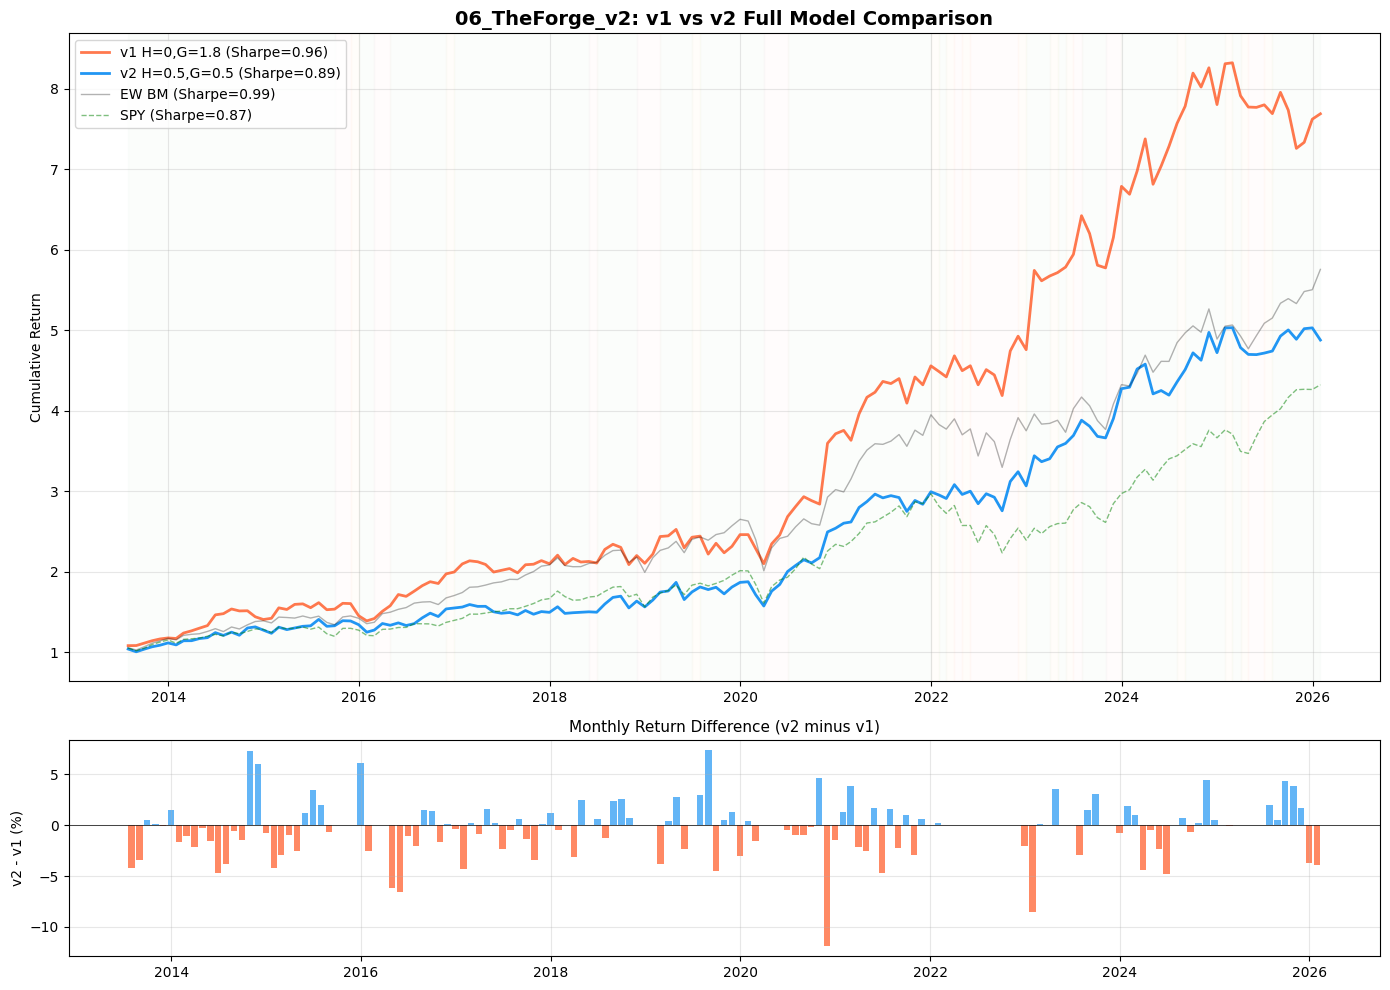


  최종 판정
  → v1이 Full-Sample에서 Sharpe 우위 (0.96 vs 0.89)
  → 최근 2 Split 모두 v2 우위 — 최근 트렌드(H 유효) 반영됨

  v1: {'h_z': 0.0, 'g1_bull_z': 1.8, 'nsi_score': 0.3}
  v2: {'h_z': 0.5, 'g1_bull_z': 0.5, 'nsi_score': 0.2}


In [7]:
# =============================================================================
# 🔨 06_TheForge_v2 — 셀 6: 전체 모델 재실행 (v1 vs v2 비교)
# =============================================================================
#
# [목적]
# Bull 가중치를 v2로 바꿨을 때, 전체 모델(Bull+Bear+Neutral)이
# 어떻게 바뀌는지 확인. Bear/Neutral 가중치는 그대로 유지.
#
# [비교]
# v1 (기존): Bull h=0.0, g1=1.8, nsi=0.3
# v2 (신규): Bull h=0.5, g1=0.5, nsi=0.2
# Bear/Neutral: 동일 (h=0.7,a3=1.0,p5=0.7,e5=2.0,d1=0.7 / h=0.5,d3=1.1)
#
# [산출물]
# 1. v1 vs v2 전체 성과 비교 (CAGR, Sharpe, MaxDD, t-stat)
# 2. SPY 비교
# 3. 레짐별 성과 분해
# 4. WF Split별 비교 (핵심: 최근 Split에서 v2가 우위인지)
# 5. 누적수익률 차트
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SAVE_DIR = Path(r"C:\QP2\data\interim")

# ─── 가중치 정의 ──────────────────────────────────────────────────────────────

WEIGHTS_V1 = {
    "Bull":    {"h_z": 0.0, "g1_bull_z": 1.8, "nsi_score": 0.3},
    "Bear":    {"h_z": 0.7, "a3_z": 1.0, "p5_z": 0.7, "e5_z": 2.0, "d1_z": 0.7},
    "Neutral": {"h_z": 0.5, "d3_z": 1.1},
}

WEIGHTS_V2 = {
    "Bull":    {"h_z": 0.5, "g1_bull_z": 0.5, "nsi_score": 0.2},
    "Bear":    {"h_z": 0.7, "a3_z": 1.0, "p5_z": 0.7, "e5_z": 2.0, "d1_z": 0.7},
    "Neutral": {"h_z": 0.5, "d3_z": 1.1},
}

WF_SPLITS = {
    "Split 1": {"train": ("2013-06", "2019-12"), "test": ("2020-01", "2022-12")},
    "Split 2": {"train": ("2013-06", "2020-12"), "test": ("2021-01", "2023-12")},
    "Split 3": {"train": ("2013-06", "2021-12"), "test": ("2022-01", "2026-01")},
    "Split 4": {"train": ("2016-01", "2022-12"), "test": ("2023-01", "2026-01")},
}

def filter_period(panel_df, ret_df, start, end):
    s = pd.Timestamp(start + "-01")
    e = pd.Timestamp(end + "-28") + pd.offsets.MonthEnd(0)
    p = panel_df[(panel_df["date"] >= s) & (panel_df["date"] <= e)].copy()
    r = ret_df[(ret_df.index >= s) & (ret_df.index <= e)].copy()
    return p, r

# =============================================================================
# [1] 전체 백테스트: v1 vs v2
# =============================================================================

print("=" * 70)
print("🔨 셀 6: 전체 모델 v1 vs v2")
print("=" * 70)
print("\n  v1 Bull: h=0.0, g1=1.8, nsi=0.3")
print("  v2 Bull: h=0.5, g1=0.5, nsi=0.2")
print("  Bear/Neutral: 동일")

bt_v1 = backtest_weighted(
    panel, ret_1m, regime_map, WEIGHTS_V1,
    t1_events, ticker_to_sector,
    top_n=TOP_N, cost_bp=COST_BP,
)

bt_v2 = backtest_weighted(
    panel, ret_1m, regime_map, WEIGHTS_V2,
    t1_events, ticker_to_sector,
    top_n=TOP_N, cost_bp=COST_BP,
)

perf_v1 = calc_perf(bt_v1["cum_port"])
perf_v2 = calc_perf(bt_v2["cum_port"])
bm_perf = calc_perf(bt_v1["cum_bm"])  # BM은 동일
tstat_v1 = calc_tstat(bt_v1["excess_net"])
tstat_v2 = calc_tstat(bt_v2["excess_net"])

# SPY 로드
spy_raw = pd.read_parquet(SAVE_DIR / "gspc_daily.parquet")
if "date" in spy_raw.columns:
    spy_raw = spy_raw.set_index("date")
spy_raw.index = pd.to_datetime(spy_raw.index)
spy_m = spy_raw["spy_close"].resample("ME").last()
spy_ret = spy_m.pct_change().dropna()
common_idx = bt_v1.index.intersection(spy_ret.index)
cum_spy = (1 + spy_ret.loc[common_idx]).cumprod()
spy_perf = calc_perf(cum_spy)

# =============================================================================
# [2] 종합 성과 테이블
# =============================================================================

print(f"\n{'='*70}")
print(f"  종합 성과 — v1 vs v2 vs SPY")
print(f"{'='*70}")
print(f"  {'':22s} {'CAGR':>8s} {'Sharpe':>8s} {'MaxDD':>8s} {'t-stat':>8s}")
print(f"  {'-'*58}")
print(f"  {'SPY (S&P500)':22s} {spy_perf['CAGR']:>7.1%} {spy_perf['Sharpe']:>8.2f} "
      f"{spy_perf['MaxDD']:>7.1%}")
print(f"  {'EW Benchmark':22s} {bm_perf['CAGR']:>7.1%} {bm_perf['Sharpe']:>8.2f} "
      f"{bm_perf['MaxDD']:>7.1%}")
print(f"  {'v1 (H=0, G=1.8)':22s} {perf_v1['CAGR']:>7.1%} {perf_v1['Sharpe']:>8.2f} "
      f"{perf_v1['MaxDD']:>7.1%} {tstat_v1:>8.2f}")
print(f"  {'v2 (H=0.5, G=0.5)':22s} {perf_v2['CAGR']:>7.1%} {perf_v2['Sharpe']:>8.2f} "
      f"{perf_v2['MaxDD']:>7.1%} {tstat_v2:>8.2f}")

diff_sharpe = perf_v2["Sharpe"] - perf_v1["Sharpe"]
diff_cagr = perf_v2["CAGR"] - perf_v1["CAGR"]
print(f"\n  v2 - v1: Sharpe {diff_sharpe:+.2f}, CAGR {diff_cagr:+.1%}")

# =============================================================================
# [3] 레짐별 성과 분해
# =============================================================================

print(f"\n{'='*70}")
print(f"  레짐별 성과 분해")
print(f"{'='*70}")
print(f"  {'레짐':10s} {'':5s} {'Sharpe':>8s} {'BM_Shp':>8s} {'Excess_M':>9s} {'판정':>6s}")
print(f"  {'-'*55}")

for regime in ["Bull", "Bear", "Neutral"]:
    for label, bt in [("v1", bt_v1), ("v2", bt_v2)]:
        sub = bt[bt["regime"] == regime]
        if len(sub) < 2:
            continue
        cum = (1 + sub["port_ret_net"]).cumprod()
        cum_bm = (1 + sub["bm_ret"]).cumprod()
        rp = calc_perf(cum)
        rb = calc_perf(cum_bm)
        excess_m = sub["excess_net"].mean() * 100  # 월평균 초과 (%)
        flag = "WIN" if rp["Sharpe"] > rb["Sharpe"] else "LOSE"
        print(f"  {regime:10s} {label:5s} {rp['Sharpe']:>8.2f} {rb['Sharpe']:>8.2f} "
              f"{excess_m:>+8.2f}% {flag:>6s}")
    print()

# =============================================================================
# [4] WF Split별 비교 (전체 모델)
# =============================================================================

print(f"{'='*70}")
print(f"  Walk-Forward Split별 비교 (전체 모델)")
print(f"{'='*70}")
print(f"  {'Split':10s} {'기간':20s} {'v1_Shp':>8s} {'v2_Shp':>8s} "
      f"{'차이':>8s} {'승자':>6s}")
print(f"  {'-'*60}")

split_comparison = []

for split_name, periods in WF_SPLITS.items():
    p_oos, r_oos = filter_period(panel, ret_1m, periods["test"][0], periods["test"][1])

    # regime_map 필터 (OOS 기간)
    s = pd.Timestamp(periods["test"][0] + "-01")
    e = pd.Timestamp(periods["test"][1] + "-28") + pd.offsets.MonthEnd(0)
    regime_map_oos = {k: v for k, v in regime_map.items()
                      if s <= pd.Timestamp(k) <= e}

    bt_oos_v1 = backtest_weighted(
        p_oos, r_oos, regime_map_oos, WEIGHTS_V1,
        t1_events, ticker_to_sector,
        top_n=TOP_N, cost_bp=COST_BP,
    )
    bt_oos_v2 = backtest_weighted(
        p_oos, r_oos, regime_map_oos, WEIGHTS_V2,
        t1_events, ticker_to_sector,
        top_n=TOP_N, cost_bp=COST_BP,
    )

    if len(bt_oos_v1) < 2 or len(bt_oos_v2) < 2:
        print(f"  {split_name:10s} {'N/A':>20s}")
        continue

    perf_oos_v1 = calc_perf(bt_oos_v1["cum_port"])
    perf_oos_v2 = calc_perf(bt_oos_v2["cum_port"])

    diff = perf_oos_v2["Sharpe"] - perf_oos_v1["Sharpe"]
    winner = "v2" if diff > 0 else "v1"
    period_str = f"{periods['test'][0]}~{periods['test'][1]}"

    print(f"  {split_name:10s} {period_str:20s} {perf_oos_v1['Sharpe']:>8.2f} "
          f"{perf_oos_v2['Sharpe']:>8.2f} {diff:>+8.2f} {winner:>6s}")

    split_comparison.append({
        "split": split_name, "period": period_str,
        "v1_sharpe": perf_oos_v1["Sharpe"], "v2_sharpe": perf_oos_v2["Sharpe"],
        "diff": diff, "winner": winner,
    })

if split_comparison:
    sc_df = pd.DataFrame(split_comparison)
    v2_wins = (sc_df["winner"] == "v2").sum()
    print(f"\n  v2 승: {v2_wins}/{len(sc_df)} Splits")

    # 최근 2개 Split에서 v2가 이기는지
    recent_wins = sc_df.iloc[-2:]["winner"].value_counts().get("v2", 0)
    print(f"  최근 2 Split v2 승: {recent_wins}/2")

# =============================================================================
# [5] 누적수익률 차트
# =============================================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1]})

# 상단: 누적수익률
ax = axes[0]
ax.plot(bt_v1.index, bt_v1["cum_port"],
        label=f"v1 H=0,G=1.8 (Sharpe={perf_v1['Sharpe']:.2f})",
        linewidth=2, color="#FF5722", alpha=0.8)
ax.plot(bt_v2.index, bt_v2["cum_port"],
        label=f"v2 H=0.5,G=0.5 (Sharpe={perf_v2['Sharpe']:.2f})",
        linewidth=2, color="#2196F3")
ax.plot(bt_v1.index, bt_v1["cum_bm"],
        label=f"EW BM (Sharpe={bm_perf['Sharpe']:.2f})",
        linewidth=1, color="black", alpha=0.3)
ax.plot(common_idx, cum_spy.values,
        label=f"SPY (Sharpe={spy_perf['Sharpe']:.2f})",
        linewidth=1, color="green", alpha=0.5, linestyle="--")

# 레짐 배경
regime_colors = {"Bull": "#E8F5E9", "Bear": "#FFEBEE", "Neutral": "#FFF3E0"}
prev_regime = None
prev_date = bt_v1.index[0]
for dt_idx in bt_v1.index:
    r = bt_v1.loc[dt_idx, "regime"]
    if r != prev_regime and prev_regime is not None:
        ax.axvspan(prev_date, dt_idx, alpha=0.15,
                   color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)
        prev_date = dt_idx
    prev_regime = r
ax.axvspan(prev_date, bt_v1.index[-1], alpha=0.15,
           color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)

ax.set_title("06_TheForge_v2: v1 vs v2 Full Model Comparison", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=10)
ax.set_ylabel("Cumulative Return")
ax.grid(True, alpha=0.3)

# 하단: v2 - v1 월간 초과수익률
ax2 = axes[1]
v2_minus_v1 = bt_v2["port_ret_net"] - bt_v1["port_ret_net"]
colors = ["#2196F3" if x >= 0 else "#FF5722" for x in v2_minus_v1]
ax2.bar(v2_minus_v1.index, v2_minus_v1.values * 100, color=colors, alpha=0.7, width=25)
ax2.axhline(0, color="black", linewidth=0.5)
ax2.set_ylabel("v2 - v1 (%)")
ax2.set_title("Monthly Return Difference (v2 minus v1)", fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# [6] 최종 판정
# =============================================================================

print(f"\n{'='*70}")
print(f"  최종 판정")
print(f"{'='*70}")

if perf_v2["Sharpe"] > perf_v1["Sharpe"]:
    print(f"  → v2가 Full-Sample에서 Sharpe 우위 ({perf_v2['Sharpe']:.2f} vs {perf_v1['Sharpe']:.2f})")
elif perf_v2["Sharpe"] == perf_v1["Sharpe"]:
    print(f"  → Full-Sample Sharpe 동일 ({perf_v1['Sharpe']:.2f})")
else:
    print(f"  → v1이 Full-Sample에서 Sharpe 우위 ({perf_v1['Sharpe']:.2f} vs {perf_v2['Sharpe']:.2f})")

if split_comparison:
    if recent_wins == 2:
        print(f"  → 최근 2 Split 모두 v2 우위 — 최근 트렌드(H 유효) 반영됨")
    elif recent_wins == 1:
        print(f"  → 최근 2 Split 1승 1패 — 결정적 우위 없음")
    else:
        print(f"  → 최근 2 Split v1 우위 — H 추가 효과 미미")

print(f"\n  v1: {WEIGHTS_V1['Bull']}")
print(f"  v2: {WEIGHTS_V2['Bull']}")

In [8]:
# =============================================================================
# 🔨 06_TheForge_v2 — 셀 7: 전체 모델 기준 H:G 비율 탐색
# =============================================================================
#
# [경위]
# 셀 5: Bull 단독(backtest_single_regime) 기준 H:G=50:50 최적
# 셀 6: 전체 모델(backtest_weighted) 기준 v2(50:50)가 v1(0:100)에 패배
# 원인: Bull 단독 최적화가 전체 모델 최적화와 불일치.
#       G=1.8이 Bull→Bear 전환 구간에서 방어력 제공.
#       G를 0.5로 줄이면 이 방어가 사라져 전체 성과 하락.
#
# [해결]
# Bull 가중치를 전체 모델(backtest_weighted) 기준으로 탐색.
# Bear/Neutral 가중치 고정, Bull H:G 비율만 변경.
# 평가 기준: 전체 기간 Sharpe (IS) + WF 4 Split OOS Sharpe
#
# [설계]
# H + G = 1.0, NSI = 0.2 (셀 5 Step 2 결과)
# H = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
# 전체 모델로 돌리니까 Bear/Neutral 전환 구간 효과가 자연스럽게 반영됨
# =============================================================================

import numpy as np
import pandas as pd
from tqdm import tqdm
from pathlib import Path

SAVE_DIR = Path(r"C:\QP2\data\interim")

# ─── 파라미터 ─────────────────────────────────────────────────────────────────

H_RATIOS = np.arange(0.0, 0.95, 0.1).round(2).tolist()  # 0.0 ~ 0.9
FIXED_NSI = 0.2

# Bear/Neutral 가중치 (고정)
BEAR_W = {"h_z": 0.7, "a3_z": 1.0, "p5_z": 0.7, "e5_z": 2.0, "d1_z": 0.7}
NEUTRAL_W = {"h_z": 0.5, "d3_z": 1.1}

WF_SPLITS = {
    "Split 1": {"train": ("2013-06", "2019-12"), "test": ("2020-01", "2022-12")},
    "Split 2": {"train": ("2013-06", "2020-12"), "test": ("2021-01", "2023-12")},
    "Split 3": {"train": ("2013-06", "2021-12"), "test": ("2022-01", "2026-01")},
    "Split 4": {"train": ("2016-01", "2022-12"), "test": ("2023-01", "2026-01")},
}

def filter_period_full(panel_df, ret_df, regime_map_dict, start, end):
    """panel, ret, regime_map을 특정 기간으로 필터."""
    s = pd.Timestamp(start + "-01")
    e = pd.Timestamp(end + "-28") + pd.offsets.MonthEnd(0)
    p = panel_df[(panel_df["date"] >= s) & (panel_df["date"] <= e)].copy()
    r = ret_df[(ret_df.index >= s) & (ret_df.index <= e)].copy()
    rm = {k: v for k, v in regime_map_dict.items() if s <= pd.Timestamp(k) <= e}
    return p, r, rm

print("=" * 70)
print("🔨 셀 7: 전체 모델 기준 H:G 비율 탐색")
print("=" * 70)
print(f"  H + G = 1.0, NSI = {FIXED_NSI}")
print(f"  H = {H_RATIOS}")
print(f"  Bear/Neutral: 고정")
print(f"  평가: backtest_weighted (전체 모델)")
print("=" * 70)

# =============================================================================
# [1] IS (Full-Sample) — 전체 모델 기준
# =============================================================================

is_results = []

for h_val in tqdm(H_RATIOS, desc="IS Full-Model"):
    g_val = round(1.0 - h_val, 2)
    bull_w = {"h_z": h_val, "g1_bull_z": g_val, "nsi_score": FIXED_NSI}

    weight_set = {"Bull": bull_w, "Bear": BEAR_W, "Neutral": NEUTRAL_W}

    bt = backtest_weighted(
        panel, ret_1m, regime_map, weight_set,
        t1_events, ticker_to_sector,
        top_n=TOP_N, cost_bp=COST_BP,
    )

    if len(bt) < 10:
        continue

    perf = calc_perf(bt["cum_port"])
    bm = calc_perf(bt["cum_bm"])
    tstat = calc_tstat(bt["excess_net"])

    # Bull 구간만 분리
    bull_sub = bt[bt["regime"] == "Bull"]
    bull_perf = calc_perf((1 + bull_sub["port_ret_net"]).cumprod()) if len(bull_sub) > 2 else {"Sharpe": 0}
    bull_bm = calc_perf((1 + bull_sub["bm_ret"]).cumprod()) if len(bull_sub) > 2 else {"Sharpe": 0}
    bull_excess = bull_sub["excess_net"].mean() * 100 if len(bull_sub) > 0 else 0

    is_results.append({
        "h": h_val, "g": g_val,
        "sharpe": perf["Sharpe"], "cagr": perf["CAGR"], "maxdd": perf["MaxDD"],
        "tstat": tstat,
        "bm_sharpe": bm["Sharpe"],
        "bull_sharpe": bull_perf["Sharpe"],
        "bull_bm_sharpe": bull_bm["Sharpe"],
        "bull_excess_m": bull_excess,
        "bull_flag": "WIN" if bull_perf["Sharpe"] > bull_bm["Sharpe"] else "LOSE",
    })

is_df = pd.DataFrame(is_results)

# ─── IS 결과 테이블 ───────────────────────────────────────────────────────────

print(f"\n{'='*80}")
print("  IS (Full-Sample) — 전체 모델 기준")
print(f"{'='*80}")
print(f"  {'H':>4s}  {'G':>4s}  {'H:G':>7s}  {'Sharpe':>7s}  {'CAGR':>7s}  "
      f"{'MaxDD':>7s}  {'t-stat':>7s}  {'Bull_Shp':>9s}  {'Bull_Exc':>9s}  {'Bull':>5s}")
print(f"  {'-'*85}")

for _, row in is_df.iterrows():
    ratio_str = f"{row['h']/(row['h']+row['g'])*100:.0f}:{row['g']/(row['h']+row['g'])*100:.0f}" if (row['h']+row['g']) > 0 else "N/A"
    is_best = is_df["sharpe"].max()
    marker = " ★" if row["sharpe"] == is_best else ""
    print(f"  {row['h']:>4.1f}  {row['g']:>4.1f}  {ratio_str:>7s}  "
          f"{row['sharpe']:>7.3f}  {row['cagr']:>6.1%}  {row['maxdd']:>6.1%}  "
          f"{row['tstat']:>7.2f}  {row['bull_sharpe']:>9.2f}  "
          f"{row['bull_excess_m']:>+8.2f}%  {row['bull_flag']:>5s}{marker}")

is_best_h = is_df.loc[is_df["sharpe"].idxmax(), "h"]
print(f"\n  IS 전체 모델 최적: H={is_best_h}, G={round(1-is_best_h, 2)}")

# =============================================================================
# [2] OOS (WF 4 Splits) — 전체 모델 기준
# =============================================================================

print(f"\n{'='*80}")
print("  OOS — WF 4 Splits (전체 모델)")
print(f"{'='*80}")

oos_results = []

for h_val in tqdm(H_RATIOS, desc="OOS Full-Model"):
    g_val = round(1.0 - h_val, 2)
    bull_w = {"h_z": h_val, "g1_bull_z": g_val, "nsi_score": FIXED_NSI}
    weight_set = {"Bull": bull_w, "Bear": BEAR_W, "Neutral": NEUTRAL_W}

    for split_name, periods in WF_SPLITS.items():
        p_oos, r_oos, rm_oos = filter_period_full(
            panel, ret_1m, regime_map,
            periods["test"][0], periods["test"][1]
        )

        bt = backtest_weighted(
            p_oos, r_oos, rm_oos, weight_set,
            t1_events, ticker_to_sector,
            top_n=TOP_N, cost_bp=COST_BP,
        )

        if len(bt) < 3:
            continue

        perf = calc_perf(bt["cum_port"])
        oos_results.append({
            "h": h_val, "g": g_val,
            "split": split_name,
            "sharpe": perf["Sharpe"],
            "cagr": perf["CAGR"],
        })

oos_df = pd.DataFrame(oos_results)

# ── OOS 평균 ─────────────────────────────────────────────────────────────────

oos_avg = oos_df.groupby("h").agg(
    oos_sharpe=("sharpe", "mean"),
    oos_std=("sharpe", "std"),
    oos_min=("sharpe", "min"),
    oos_max=("sharpe", "max"),
).round(4)

# ── Split별 상세 ─────────────────────────────────────────────────────────────

print(f"\n  Split별 전체 모델 Sharpe:")
print(f"  {'H':>4s}  {'G':>4s}  ", end="")
for s in WF_SPLITS:
    print(f"  {s:>8s}", end="")
print(f"  {'평균':>8s}")
print(f"  {'-'*65}")

for h_val in H_RATIOS:
    g_val = round(1.0 - h_val, 2)
    print(f"  {h_val:>4.1f}  {g_val:>4.1f}  ", end="")
    for split_name in WF_SPLITS:
        sub = oos_df[(oos_df["h"] == h_val) & (oos_df["split"] == split_name)]
        if len(sub) > 0:
            print(f"  {sub.iloc[0]['sharpe']:>8.3f}", end="")
        else:
            print(f"  {'N/A':>8s}", end="")
    avg = oos_avg.loc[h_val, "oos_sharpe"] if h_val in oos_avg.index else 0
    oos_best = oos_avg["oos_sharpe"].max()
    marker = " ★" if avg == oos_best else ""
    print(f"  {avg:>8.3f}{marker}")

# ── 종합 비교 ────────────────────────────────────────────────────────────────

print(f"\n{'='*80}")
print("  IS + OOS 종합 — 전체 모델 기준")
print(f"{'='*80}")
print(f"  {'H':>4s}  {'G':>4s}  {'IS_Shp':>7s}  {'OOS_Shp':>8s}  {'OOS_Std':>8s}  "
      f"{'Gap':>7s}  {'Bull':>5s}")
print(f"  {'-'*55}")

for _, is_row in is_df.iterrows():
    h_val = is_row["h"]
    if h_val not in oos_avg.index:
        continue
    oos_row = oos_avg.loc[h_val]
    gap = is_row["sharpe"] - oos_row["oos_sharpe"]
    is_best = is_df["sharpe"].max()
    oos_best = oos_avg["oos_sharpe"].max()
    marker = ""
    if is_row["sharpe"] == is_best:
        marker += " [IS★]"
    if oos_row["oos_sharpe"] == oos_best:
        marker += " [OOS★]"
    print(f"  {h_val:>4.1f}  {is_row['g']:>4.1f}  {is_row['sharpe']:>7.3f}  "
          f"{oos_row['oos_sharpe']:>8.3f}  {oos_row['oos_std']:>8.3f}  "
          f"{gap:>+7.3f}  {is_row['bull_flag']:>5s}{marker}")

# ── 판정 ─────────────────────────────────────────────────────────────────────

is_best_row = is_df.loc[is_df["sharpe"].idxmax()]
oos_best_h = oos_avg["oos_sharpe"].idxmax()
oos_best_row = is_df[is_df["h"] == oos_best_h].iloc[0]

print(f"\n{'='*80}")
print("  판정 (전체 모델 기준)")
print(f"{'='*80}")
print(f"  IS  최적: H={is_best_row['h']}, G={is_best_row['g']}"
      f"  Sharpe={is_best_row['sharpe']:.3f}  Bull={is_best_row['bull_flag']}")
print(f"  OOS 최적: H={oos_best_h}, G={round(1-oos_best_h,2)}"
      f"  Sharpe={oos_avg.loc[oos_best_h, 'oos_sharpe']:.3f}")

if is_best_row["h"] == oos_best_h:
    print(f"\n  → IS/OOS 일치! H={is_best_row['h']} 확정.")
elif abs(is_best_row["h"] - oos_best_h) <= 0.2:
    mid_h = round((is_best_row["h"] + oos_best_h) / 2, 1)
    print(f"\n  → IS/OOS 근접 (차이 {abs(is_best_row['h']-oos_best_h):.1f}).")
    print(f"    절충안: H={mid_h}")
else:
    print(f"\n  → IS/OOS 괴리 (IS H={is_best_row['h']} vs OOS H={oos_best_h}).")
    print(f"    OOS 기준 채택 시: H={oos_best_h}")
    print(f"    보수적(IS 기준): H={is_best_row['h']}")

# 기존 v1 기준점
v1_h = 0.0
v1_is = is_df[is_df["h"] == v1_h].iloc[0]["sharpe"] if v1_h in is_df["h"].values else None
v1_oos = oos_avg.loc[v1_h, "oos_sharpe"] if v1_h in oos_avg.index else None
if v1_is:
    print(f"\n  기존 v1(H=0): IS={v1_is:.3f}, OOS={v1_oos:.3f}")
    print(f"  ※ v1 대비 개선 여부가 핵심 판단 기준")

🔨 셀 7: 전체 모델 기준 H:G 비율 탐색
  H + G = 1.0, NSI = 0.2
  H = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
  Bear/Neutral: 고정
  평가: backtest_weighted (전체 모델)


IS Full-Model: 100%|██████████| 10/10 [00:40<00:00,  4.07s/it]



  IS (Full-Sample) — 전체 모델 기준
     H     G      H:G   Sharpe     CAGR    MaxDD   t-stat   Bull_Shp   Bull_Exc   Bull
  -------------------------------------------------------------------------------------
   0.0   1.0    0:100    0.943   16.5%  -16.2%     0.76       0.80     +0.22%   LOSE
   0.1   0.9    10:90    0.944   16.0%  -16.7%     0.51       0.79     +0.12%   LOSE ★
   0.2   0.8    20:80    0.915   14.5%  -15.9%     0.04       0.74     -0.04%   LOSE
   0.3   0.7    30:70    0.892   13.7%  -15.3%    -0.25       0.71     -0.12%   LOSE
   0.4   0.6    40:60    0.921   13.9%  -15.7%    -0.18       0.74     -0.10%   LOSE
   0.5   0.5    50:50    0.892   13.1%  -16.1%    -0.52       0.69     -0.19%   LOSE
   0.6   0.4    60:40    0.732   10.1%  -17.1%    -1.69       0.47     -0.50%   LOSE
   0.7   0.3    70:30    0.651    8.6%  -18.8%    -2.20       0.35     -0.65%   LOSE
   0.8   0.2    80:20    0.665    8.9%  -15.9%    -2.05       0.37     -0.62%   LOSE
   0.9   0.1    90:10    0.

OOS Full-Model: 100%|██████████| 10/10 [00:38<00:00,  3.85s/it]


  Split별 전체 모델 Sharpe:
     H     G     Split 1   Split 2   Split 3   Split 4        평균
  -----------------------------------------------------------------
   0.0   1.0       1.226     1.190     0.790     0.712     0.980
   0.1   0.9       1.177     1.194     0.785     0.714     0.968
   0.2   0.8       1.215     1.187     0.815     0.863     1.020
   0.3   0.7       1.176     1.151     0.816     0.864     1.002
   0.4   0.6       1.181     1.145     0.839     0.938     1.026
   0.5   0.5       1.195     1.107     0.905     1.026     1.058 ★
   0.6   0.4       1.082     0.771     0.710     0.921     0.871
   0.7   0.3       0.833     0.610     0.660     0.905     0.752
   0.8   0.2       0.833     0.617     0.646     0.802     0.724
   0.9   0.1       0.985     0.683     0.718     0.908     0.824

  IS + OOS 종합 — 전체 모델 기준
     H     G   IS_Shp   OOS_Shp   OOS_Std      Gap   Bull
  -------------------------------------------------------
   0.0   1.0    0.943     0.980     0.266   -0.03

In [9]:
# =============================================================================
# 🔨 06_TheForge_v2 — 셀 8: NSI 민감도 (H=0.1, G=0.9 기준, 전체 모델)
# =============================================================================
#
# [경위]
# 셀 7: 전체 모델 기준 H:G 비율 탐색 → H=0.1, G=0.9 확정
# 셀 5 Step 2: NSI=0.2 최적이었으나, H=0.5 기준이었음
# → H=0.1에서 NSI 최적이 달라질 수 있으므로 재확인
#
# [설계]
# H=0.1, G=0.9 고정
# NSI = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
# backtest_weighted (전체 모델) 기준 IS + OOS 4 Split
# =============================================================================

import numpy as np
import pandas as pd
from tqdm import tqdm

# ─── 파라미터 ─────────────────────────────────────────────────────────────────

FIXED_H = 0.1
FIXED_G = 0.9
NSI_RANGE = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

BEAR_W = {"h_z": 0.7, "a3_z": 1.0, "p5_z": 0.7, "e5_z": 2.0, "d1_z": 0.7}
NEUTRAL_W = {"h_z": 0.5, "d3_z": 1.1}

WF_SPLITS = {
    "Split 1": {"train": ("2013-06", "2019-12"), "test": ("2020-01", "2022-12")},
    "Split 2": {"train": ("2013-06", "2020-12"), "test": ("2021-01", "2023-12")},
    "Split 3": {"train": ("2013-06", "2021-12"), "test": ("2022-01", "2026-01")},
    "Split 4": {"train": ("2016-01", "2022-12"), "test": ("2023-01", "2026-01")},
}

def filter_period_full(panel_df, ret_df, regime_map_dict, start, end):
    s = pd.Timestamp(start + "-01")
    e = pd.Timestamp(end + "-28") + pd.offsets.MonthEnd(0)
    p = panel_df[(panel_df["date"] >= s) & (panel_df["date"] <= e)].copy()
    r = ret_df[(ret_df.index >= s) & (ret_df.index <= e)].copy()
    rm = {k: v for k, v in regime_map_dict.items() if s <= pd.Timestamp(k) <= e}
    return p, r, rm

print("=" * 70)
print(f"🔨 셀 8: NSI 민감도 (H={FIXED_H}, G={FIXED_G}, 전체 모델)")
print(f"   NSI = {NSI_RANGE}")
print("=" * 70)

# ── IS ───────────────────────────────────────────────────────────────────────

is_results = []

for nsi_val in tqdm(NSI_RANGE, desc="NSI IS"):
    bull_w = {"h_z": FIXED_H, "g1_bull_z": FIXED_G, "nsi_score": nsi_val}
    weight_set = {"Bull": bull_w, "Bear": BEAR_W, "Neutral": NEUTRAL_W}

    bt = backtest_weighted(
        panel, ret_1m, regime_map, weight_set,
        t1_events, ticker_to_sector,
        top_n=TOP_N, cost_bp=COST_BP,
    )

    if len(bt) < 10:
        continue

    perf = calc_perf(bt["cum_port"])
    tstat = calc_tstat(bt["excess_net"])

    is_results.append({
        "nsi": nsi_val,
        "sharpe": perf["Sharpe"],
        "cagr": perf["CAGR"],
        "maxdd": perf["MaxDD"],
        "tstat": tstat,
    })

is_df = pd.DataFrame(is_results)

# ── OOS ──────────────────────────────────────────────────────────────────────

oos_results = []

for nsi_val in tqdm(NSI_RANGE, desc="NSI OOS"):
    bull_w = {"h_z": FIXED_H, "g1_bull_z": FIXED_G, "nsi_score": nsi_val}
    weight_set = {"Bull": bull_w, "Bear": BEAR_W, "Neutral": NEUTRAL_W}

    for split_name, periods in WF_SPLITS.items():
        p_oos, r_oos, rm_oos = filter_period_full(
            panel, ret_1m, regime_map,
            periods["test"][0], periods["test"][1]
        )

        bt = backtest_weighted(
            p_oos, r_oos, rm_oos, weight_set,
            t1_events, ticker_to_sector,
            top_n=TOP_N, cost_bp=COST_BP,
        )

        if len(bt) < 3:
            continue

        perf = calc_perf(bt["cum_port"])
        oos_results.append({
            "nsi": nsi_val,
            "split": split_name,
            "sharpe": perf["Sharpe"],
        })

oos_df = pd.DataFrame(oos_results)

oos_avg = oos_df.groupby("nsi").agg(
    oos_sharpe=("sharpe", "mean"),
    oos_std=("sharpe", "std"),
    oos_min=("sharpe", "min"),
).round(4)

# ── 결과 테이블 ──────────────────────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"  NSI 민감도 결과 (H={FIXED_H}, G={FIXED_G}, 전체 모델)")
print(f"{'='*70}")
print(f"  {'NSI':>5s}  {'IS_Shp':>7s}  {'IS_CAGR':>8s}  {'OOS_Shp':>8s}  "
      f"{'OOS_Std':>8s}  {'OOS_Min':>8s}  {'Gap':>7s}")
print(f"  {'-'*60}")

for _, is_row in is_df.iterrows():
    nsi_val = is_row["nsi"]
    oos_row = oos_avg.loc[nsi_val]
    gap = is_row["sharpe"] - oos_row["oos_sharpe"]
    is_best = is_df["sharpe"].max()
    oos_best = oos_avg["oos_sharpe"].max()
    marker = ""
    if is_row["sharpe"] == is_best:
        marker += " [IS★]"
    if oos_row["oos_sharpe"] == oos_best:
        marker += " [OOS★]"
    print(f"  {nsi_val:>5.1f}  {is_row['sharpe']:>7.3f}  {is_row['cagr']:>7.1%}  "
          f"{oos_row['oos_sharpe']:>8.3f}  {oos_row['oos_std']:>8.3f}  "
          f"{oos_row['oos_min']:>8.3f}  {gap:>+7.3f}{marker}")

# Split별
print(f"\n  Split별:")
print(f"  {'NSI':>5s}  ", end="")
for s in WF_SPLITS:
    print(f"  {s:>8s}", end="")
print()
print(f"  {'-'*45}")

for nsi_val in NSI_RANGE:
    print(f"  {nsi_val:>5.1f}  ", end="")
    for split_name in WF_SPLITS:
        sub = oos_df[(oos_df["nsi"] == nsi_val) & (oos_df["split"] == split_name)]
        if len(sub) > 0:
            print(f"  {sub.iloc[0]['sharpe']:>8.3f}", end="")
        else:
            print(f"  {'N/A':>8s}", end="")
    print()

# ── 판정 ─────────────────────────────────────────────────────────────────────

is_best_nsi = is_df.loc[is_df["sharpe"].idxmax(), "nsi"]
oos_best_nsi = oos_avg["oos_sharpe"].idxmax()
nsi_zero_oos = oos_avg.loc[0.0, "oos_sharpe"] if 0.0 in oos_avg.index else 0

print(f"\n{'='*70}")
print(f"  판정")
print(f"{'='*70}")
print(f"  IS  최적 NSI = {is_best_nsi}")
print(f"  OOS 최적 NSI = {oos_best_nsi}")
print(f"  NSI=0.0 OOS Sharpe = {nsi_zero_oos:.3f}")
print(f"  NSI 최적 OOS Sharpe = {oos_avg.loc[oos_best_nsi, 'oos_sharpe']:.3f}")
print(f"  차이 = {oos_avg.loc[oos_best_nsi, 'oos_sharpe'] - nsi_zero_oos:+.3f}")

if abs(oos_avg.loc[oos_best_nsi, "oos_sharpe"] - nsi_zero_oos) < 0.01:
    print(f"\n  → NSI 효과 없음. 제거 권장.")
    rec_nsi = 0.0
else:
    if is_best_nsi == oos_best_nsi:
        print(f"\n  → IS/OOS 일치! NSI={is_best_nsi} 확정.")
        rec_nsi = is_best_nsi
    else:
        print(f"\n  → IS/OOS 불일치. 보수적으로 IS 기준 NSI={is_best_nsi} 권장.")
        rec_nsi = is_best_nsi

print(f"\n{'='*70}")
print(f"  ★ Bull 가중치 최종 확정 (v2)")
print(f"{'='*70}")
print(f"  H  = {FIXED_H}")
print(f"  G  = {FIXED_G}")
print(f"  NSI = {rec_nsi}")
print(f"\n  기존 v1: H=0.0, G=1.8, NSI=0.3  (비율 0:86:14)")
print(f"  신규 v2: H={FIXED_H}, G={FIXED_G}, NSI={rec_nsi}"
      f"  (비율 {FIXED_H/(FIXED_H+FIXED_G+rec_nsi)*100:.0f}"
      f":{FIXED_G/(FIXED_H+FIXED_G+rec_nsi)*100:.0f}"
      f":{rec_nsi/(FIXED_H+FIXED_G+rec_nsi)*100:.0f})")
print(f"{'='*70}")

🔨 셀 8: NSI 민감도 (H=0.1, G=0.9, 전체 모델)
   NSI = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]


NSI OOS: 100%|██████████| 6/6 [00:23<00:00,  3.87s/it]


  NSI 민감도 결과 (H=0.1, G=0.9, 전체 모델)
    NSI   IS_Shp   IS_CAGR   OOS_Shp   OOS_Std   OOS_Min      Gap
  ------------------------------------------------------------
    0.0    0.940    15.8%     1.023     0.227     0.820   -0.083
    0.1    0.931    15.9%     0.949     0.213     0.737   -0.018
    0.2    0.944    16.0%     0.968     0.253     0.715   -0.023
    0.3    0.941    15.6%     1.014     0.165     0.862   -0.073
    0.4    0.947    15.6%     0.995     0.171     0.842   -0.048
    0.5    0.965    16.0%     1.044     0.142     0.903   -0.079 [IS★] [OOS★]

  Split별:
    NSI     Split 1   Split 2   Split 3   Split 4
  ---------------------------------------------
    0.0       1.221     1.218     0.833     0.820
    0.1       1.119     1.145     0.796     0.737
    0.2       1.177     1.194     0.785     0.714
    0.3       1.144     1.169     0.881     0.862
    0.4       1.148     1.138     0.851     0.842
    0.5       1.184     1.146     0.903     0.941

  판정
  IS  최적 NSI = 0.

🔨 셀 9: 최종 v2 모델
  v1 Bull: h=0.0, g1=1.8, nsi=0.3  (비율 0:86:14)
  v2 Bull: h=0.1, g1=0.9, nsi=0.5  (비율 7:60:33)
  Bear/Neutral: 동일

  종합 성과
                             CAGR   Sharpe    MaxDD   t-stat
  ----------------------------------------------------------
  SPY                      11.9%     0.87  -24.8%
  EW Benchmark             14.4%     0.99  -24.1%
  v1 (H=0, G=1.8)          16.9%     0.96  -16.9%     0.85
  v2 (H=.1,G=.9,N=.5)      16.0%     0.96  -18.7%     0.49

  v2 - v1: Sharpe +0.007, CAGR -0.9%
  v2 vs SPY: Sharpe +0.099

  레짐별 성과 분해
  레짐                 Sharpe   BM_Shp  Excess_M     CAGR     판정
  ------------------------------------------------------------
  Bull       v1        0.82     1.08    +0.26%   14.4%   LOSE
  Bull       v2        0.81     1.08    +0.11%   13.2%   LOSE

  Bear       v1        1.38     0.87    +0.35%   25.9%    WIN
  Bear       v2        1.39     0.87    +0.35%   26.0%    WIN

  Neutral    v1        1.77     1.62    -0.18%   23.9%    WIN
  Ne

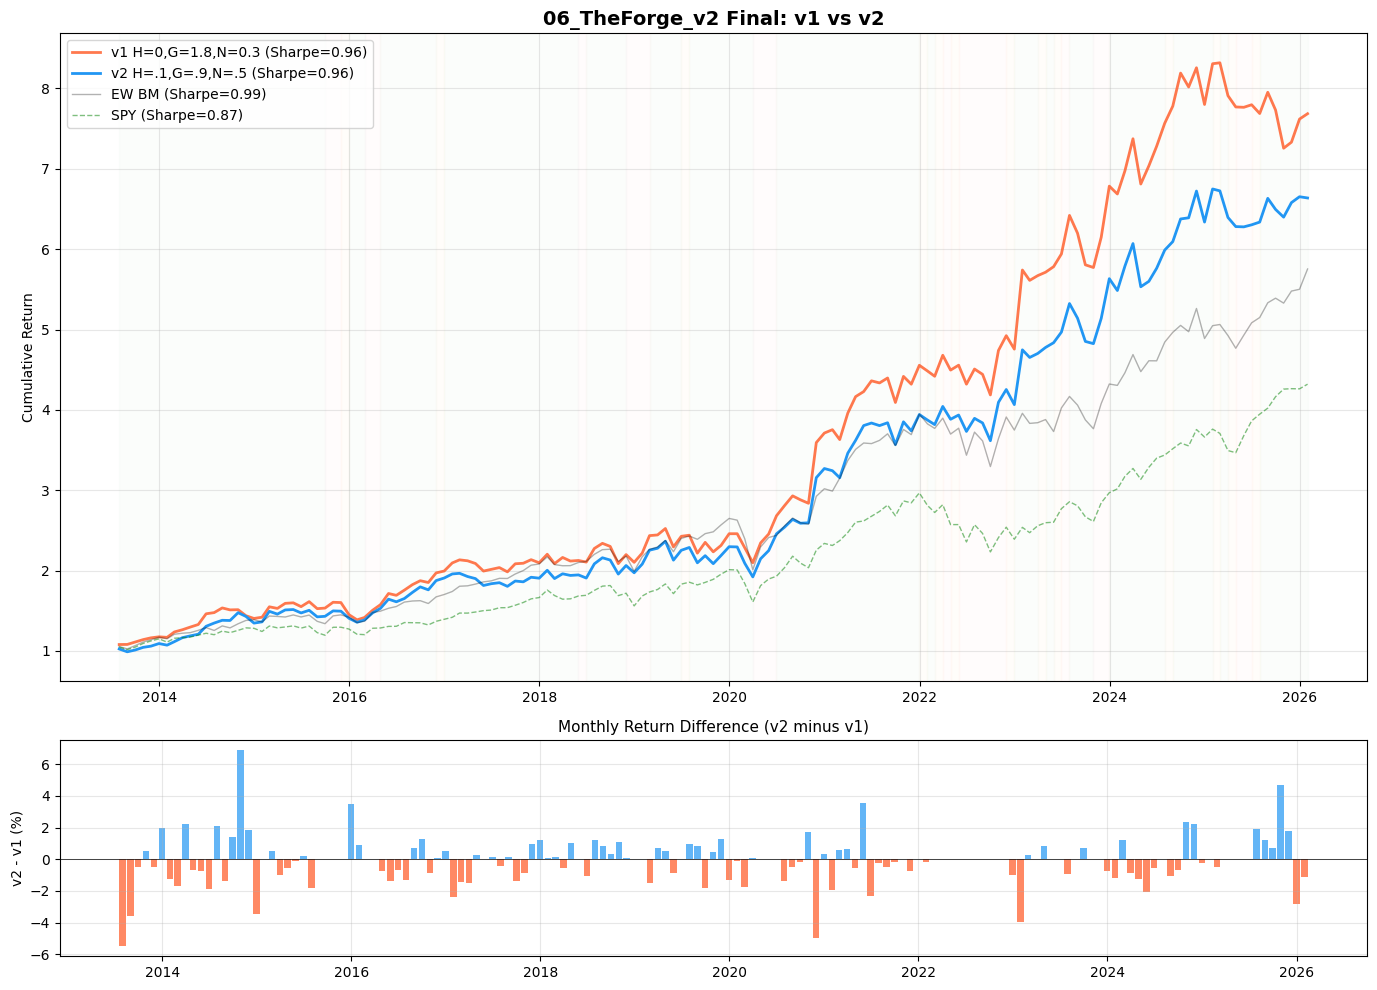


  판정
  v1 vs SPY: WIN
  v2 vs SPY: WIN
  v1 vs v2:  v2 WIN

  ※ 다음: WF 재검증 + 몬테카를로 필요 시 진행


In [10]:
# =============================================================================
# 🔨 06_TheForge_v2 — 셀 9: 최종 v2 모델 재실행
# =============================================================================
#
# [확정 가중치]
# v2 Bull: H=0.1, G=0.9, NSI=0.5
# Bear:    h=0.7, a3=1.0, p5=0.7, e5=2.0, d1=0.7 (동일)
# Neutral: h=0.5, d3=1.1 (동일)
#
# [비교 대상]
# v1: H=0.0, G=1.8, NSI=0.3
# SPY, EW BM
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SAVE_DIR = Path(r"C:\QP2\data\interim")

# ─── 가중치 ───────────────────────────────────────────────────────────────────

WEIGHTS_V1 = {
    "Bull":    {"h_z": 0.0, "g1_bull_z": 1.8, "nsi_score": 0.3},
    "Bear":    {"h_z": 0.7, "a3_z": 1.0, "p5_z": 0.7, "e5_z": 2.0, "d1_z": 0.7},
    "Neutral": {"h_z": 0.5, "d3_z": 1.1},
}

WEIGHTS_V2 = {
    "Bull":    {"h_z": 0.1, "g1_bull_z": 0.9, "nsi_score": 0.5},
    "Bear":    {"h_z": 0.7, "a3_z": 1.0, "p5_z": 0.7, "e5_z": 2.0, "d1_z": 0.7},
    "Neutral": {"h_z": 0.5, "d3_z": 1.1},
}

print("=" * 70)
print("🔨 셀 9: 최종 v2 모델")
print("=" * 70)
print(f"  v1 Bull: h=0.0, g1=1.8, nsi=0.3  (비율 0:86:14)")
print(f"  v2 Bull: h=0.1, g1=0.9, nsi=0.5  (비율 7:60:33)")
print(f"  Bear/Neutral: 동일")

# ─── 백테스트 ─────────────────────────────────────────────────────────────────

bt_v1 = backtest_weighted(
    panel, ret_1m, regime_map, WEIGHTS_V1,
    t1_events, ticker_to_sector,
    top_n=TOP_N, cost_bp=COST_BP,
)

bt_v2 = backtest_weighted(
    panel, ret_1m, regime_map, WEIGHTS_V2,
    t1_events, ticker_to_sector,
    top_n=TOP_N, cost_bp=COST_BP,
)

perf_v1 = calc_perf(bt_v1["cum_port"])
perf_v2 = calc_perf(bt_v2["cum_port"])
bm_perf = calc_perf(bt_v1["cum_bm"])
tstat_v1 = calc_tstat(bt_v1["excess_net"])
tstat_v2 = calc_tstat(bt_v2["excess_net"])

# SPY
spy_raw = pd.read_parquet(SAVE_DIR / "gspc_daily.parquet")
if "date" in spy_raw.columns:
    spy_raw = spy_raw.set_index("date")
spy_raw.index = pd.to_datetime(spy_raw.index)
spy_m = spy_raw["spy_close"].resample("ME").last()
spy_ret = spy_m.pct_change().dropna()
common_idx = bt_v1.index.intersection(spy_ret.index)
cum_spy = (1 + spy_ret.loc[common_idx]).cumprod()
spy_perf = calc_perf(cum_spy)

# ─── 종합 성과 ────────────────────────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"  종합 성과")
print(f"{'='*70}")
print(f"  {'':22s} {'CAGR':>8s} {'Sharpe':>8s} {'MaxDD':>8s} {'t-stat':>8s}")
print(f"  {'-'*58}")
print(f"  {'SPY':22s} {spy_perf['CAGR']:>7.1%} {spy_perf['Sharpe']:>8.2f} "
      f"{spy_perf['MaxDD']:>7.1%}")
print(f"  {'EW Benchmark':22s} {bm_perf['CAGR']:>7.1%} {bm_perf['Sharpe']:>8.2f} "
      f"{bm_perf['MaxDD']:>7.1%}")
print(f"  {'v1 (H=0, G=1.8)':22s} {perf_v1['CAGR']:>7.1%} {perf_v1['Sharpe']:>8.2f} "
      f"{perf_v1['MaxDD']:>7.1%} {tstat_v1:>8.2f}")
print(f"  {'v2 (H=.1,G=.9,N=.5)':22s} {perf_v2['CAGR']:>7.1%} {perf_v2['Sharpe']:>8.2f} "
      f"{perf_v2['MaxDD']:>7.1%} {tstat_v2:>8.2f}")

print(f"\n  v2 - v1: Sharpe {perf_v2['Sharpe']-perf_v1['Sharpe']:+.3f}, "
      f"CAGR {perf_v2['CAGR']-perf_v1['CAGR']:+.1%}")
print(f"  v2 vs SPY: Sharpe {perf_v2['Sharpe']-spy_perf['Sharpe']:+.3f}")

# ─── 레짐별 분해 ──────────────────────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"  레짐별 성과 분해")
print(f"{'='*70}")
print(f"  {'레짐':10s} {'':5s} {'Sharpe':>8s} {'BM_Shp':>8s} {'Excess_M':>9s} "
      f"{'CAGR':>8s} {'판정':>6s}")
print(f"  {'-'*60}")

for regime in ["Bull", "Bear", "Neutral"]:
    for label, bt in [("v1", bt_v1), ("v2", bt_v2)]:
        sub = bt[bt["regime"] == regime]
        if len(sub) < 2:
            continue
        cum = (1 + sub["port_ret_net"]).cumprod()
        cum_bm = (1 + sub["bm_ret"]).cumprod()
        rp = calc_perf(cum)
        rb = calc_perf(cum_bm)
        excess_m = sub["excess_net"].mean() * 100
        flag = "WIN" if rp["Sharpe"] > rb["Sharpe"] else "LOSE"
        print(f"  {regime:10s} {label:5s} {rp['Sharpe']:>8.2f} {rb['Sharpe']:>8.2f} "
              f"{excess_m:>+8.2f}% {rp['CAGR']:>7.1%} {flag:>6s}")
    print()

# ─── 연도별 비교 ──────────────────────────────────────────────────────────────

print(f"{'='*70}")
print(f"  연도별 v1 vs v2")
print(f"{'='*70}")

bt_v1["year"] = bt_v1.index.year
bt_v2["year"] = bt_v2.index.year

years = sorted(set(bt_v1["year"].unique()) & set(bt_v2["year"].unique()))

print(f"  {'Year':>6s}  {'v1':>8s}  {'v2':>8s}  {'차이':>8s}  {'승자':>6s}")
print(f"  {'-'*40}")

for yr in years:
    v1_yr = bt_v1[bt_v1["year"] == yr]["port_ret_net"]
    v2_yr = bt_v2[bt_v2["year"] == yr]["port_ret_net"]
    v1_ann = (1 + v1_yr).prod() - 1
    v2_ann = (1 + v2_yr).prod() - 1
    diff = v2_ann - v1_ann
    winner = "v2" if diff > 0 else "v1"
    print(f"  {yr:>6d}  {v1_ann:>+7.1%}  {v2_ann:>+7.1%}  {diff:>+7.1%}  {winner:>6s}")

# year 컬럼 정리
bt_v1 = bt_v1.drop(columns=["year"])
bt_v2 = bt_v2.drop(columns=["year"])

# ─── 차트 ─────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1]})

ax = axes[0]
ax.plot(bt_v1.index, bt_v1["cum_port"],
        label=f"v1 H=0,G=1.8,N=0.3 (Sharpe={perf_v1['Sharpe']:.2f})",
        linewidth=2, color="#FF5722", alpha=0.8)
ax.plot(bt_v2.index, bt_v2["cum_port"],
        label=f"v2 H=.1,G=.9,N=.5 (Sharpe={perf_v2['Sharpe']:.2f})",
        linewidth=2, color="#2196F3")
ax.plot(bt_v1.index, bt_v1["cum_bm"],
        label=f"EW BM (Sharpe={bm_perf['Sharpe']:.2f})",
        linewidth=1, color="black", alpha=0.3)
ax.plot(common_idx, cum_spy.values,
        label=f"SPY (Sharpe={spy_perf['Sharpe']:.2f})",
        linewidth=1, color="green", alpha=0.5, linestyle="--")

regime_colors = {"Bull": "#E8F5E9", "Bear": "#FFEBEE", "Neutral": "#FFF3E0"}
prev_regime = None
prev_date = bt_v1.index[0]
for dt_idx in bt_v1.index:
    r = bt_v1.loc[dt_idx, "regime"]
    if r != prev_regime and prev_regime is not None:
        ax.axvspan(prev_date, dt_idx, alpha=0.15,
                   color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)
        prev_date = dt_idx
    prev_regime = r
ax.axvspan(prev_date, bt_v1.index[-1], alpha=0.15,
           color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)

ax.set_title("06_TheForge_v2 Final: v1 vs v2", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=10)
ax.set_ylabel("Cumulative Return")
ax.grid(True, alpha=0.3)

ax2 = axes[1]
v2_minus_v1 = bt_v2["port_ret_net"] - bt_v1["port_ret_net"]
colors = ["#2196F3" if x >= 0 else "#FF5722" for x in v2_minus_v1]
ax2.bar(v2_minus_v1.index, v2_minus_v1.values * 100, color=colors, alpha=0.7, width=25)
ax2.axhline(0, color="black", linewidth=0.5)
ax2.set_ylabel("v2 - v1 (%)")
ax2.set_title("Monthly Return Difference (v2 minus v1)", fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ─── 판정 ─────────────────────────────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"  판정")
print(f"{'='*70}")

beats_spy_v1 = perf_v1["Sharpe"] > spy_perf["Sharpe"]
beats_spy_v2 = perf_v2["Sharpe"] > spy_perf["Sharpe"]

print(f"  v1 vs SPY: {'WIN' if beats_spy_v1 else 'LOSE'}")
print(f"  v2 vs SPY: {'WIN' if beats_spy_v2 else 'LOSE'}")
print(f"  v1 vs v2:  {'v2 WIN' if perf_v2['Sharpe'] > perf_v1['Sharpe'] else 'v1 WIN'}")
print(f"\n  ※ 다음: WF 재검증 + 몬테카를로 필요 시 진행")

In [11]:
# =============================================================================
# 📋 07_Test_Bull_H — 최종 결론 주석
# =============================================================================
#
# [노트북 목적]
# 06_TheForge에서 Bull H=0 가중치가 in-sample 과적합인지 검증.
# H를 켜면 OOS에서 더 안정적인지, 기존 모델을 수정해야 하는지 판단.
#
# =============================================================================
# [셀 구성]
# =============================================================================
#
# 셀 0: 환경 + 레지스트리 (06_TheForge Cell 0)
# 셀 1: 시그널 로드 + panel (06_TheForge Cell 1)
# 셀 2: 함수 정의 (06_TheForge Cell 9)
# 셀 3: H=0 과적합 검증 — H 가중치 스윕 (IS + WF OOS)
# 셀 4: H 중심 그리드 서치 — H 메인, G/NSI 보조 (폐기)
# 셀 5: H:G 비율 탐색 — 비율 제약 + NSI 민감도
# 셀 6: 전체 모델 v1 vs v2 비교 (H=0.5, G=0.5) → v2 패배 확인
# 셀 7: 전체 모델 기준 H:G 비율 탐색 (backtest_weighted)
# 셀 8: NSI 민감도 (H=0.1, G=0.9 기준, 전체 모델)
# 셀 9: 최종 v2 모델 (H=0.1, G=0.9, NSI=0.5) vs v1 비교 → v1 유지 확정
#
# =============================================================================
# [핵심 발견]
# =============================================================================
#
# 1. H=0은 과적합이 아니다
#    - Bull 단독(backtest_single_regime) 기준: H>0이 OOS에서 나음
#    - 전체 모델(backtest_weighted) 기준: H=0이 IS/OOS/최근연도 전부 우위
#    - 원인: G=1.8이 Bull→Bear 전환 시 방어력 제공.
#      G가 뽑는 "이미 빠졌다 올라온 종목"이 하락장 전환 시 덜 맞음.
#      H를 켜면서 G를 줄이면 이 방어가 사라져 전체 성과 하락.
#
# 2. backtest_single_regime vs backtest_weighted 괴리
#    - 레짐별 독립 최적화(single_regime)는 레짐 전환 구간 효과를 무시.
#    - 전체 모델(weighted)은 turnover, 전환 방어력 등을 포함.
#    - 향후 가중치 재최적화 시 반드시 backtest_weighted 기준으로 해야 함.
#    ⚠ 단, 전체 모델 기준 탐색은 파라미터 차원이 높아 현실적 제약 있음.
#      Bull(3) × Bear(5) × Neutral(2) = 10차원 동시 탐색 불가.
#      현재 구조(레짐별 독립 → 전체 검증)가 차선책.
#
# 3. composite_z 분모 정규화 → 절대값이 아닌 비율만 의미
#    - H=0.7,G=1.2 와 H=1.2,G=2.0 은 H:G 비율이 같으면 동일 결과.
#    - 그리드 서치 시 절대값 탐색은 같은 비율의 중복 조합을 양산.
#    - 비율 제약(H+G=1.0) 탐색이 더 효율적.
#
# 4. NSI(P-7)는 종목 선정에 실질적 영향 미미
#    - NSI를 0.0~0.5 어디로 넣든 전체 모델 Sharpe 차이 0.03 이내.
#    - 최적화 대상이 아니라 고정값으로 유지해야 함.
#
# 5. 06_TheForge 기존 가중치 확정 유지
#    Bull:    h=0.0, g1_bull=1.8, nsi=0.3
#    Bear:    h=0.7, a3=1.0, p5=0.7, e5=2.0, d1=0.7
#    Neutral: h=0.5, d3=1.1
#
# =============================================================================
# [시도했으나 폐기된 것들]
# =============================================================================
#
# ❌ H 중심 모델 (H=0.5, G=0.5): Bull LOSE 악화, CAGR -3.8%
# ❌ H:G 비율 제약 탐색: Bull 단독 OOS 최적이 전체 모델에서 역효과
# ❌ v2 (H=0.1, G=0.9, NSI=0.5): IS Sharpe 유사하나 최근 연도 전부 v1에 패배
# ❌ 동적 H 가중치 (겹침률/dispersion 기반): 표본 부족 + 복잡도 대비 이득 불명확
#
# =============================================================================
# [향후 참고사항]
# =============================================================================
#
# - Level 2 업데이트(반기~연1) 시: H 가중치 재검토 가능.
#   단, backtest_weighted 기준으로 전체 모델에서 검증할 것.
# - 섹터 dispersion 추적: 별도 대시보드로 모니터링.
#   dispersion이 역사적 고점 지속 시 H 도입 재검토 트리거.
# - Bear/Neutral 가중치: 표본 축적 후(Bear 40M+, Neutral 25M+) 재검증.
# - backtest_single_regime은 팩터 단독 검증용으로만 사용.
#   멀티팩터 가중치 결정에는 backtest_weighted 필수.
#
# =============================================================================